## 1 Modelamiento Predictivo

## 1.1 Importar librerías y cargar datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
from google.colab import auth
auth.authenticate_user()

## 1.2 Llamar a la base de datos

Buscamos predecir el nivel de combustible de los camiones CAEX
en esta seccion, y para ello comenzamos nuestro analisis exploratorio realizando un JOIN LEFT con las tablas sensor_motor
y sensor_combustible y asi generar un dataframe que nos provea mayor información.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================
# CARGA DE TABLAS (CSV) + CONSTRUCCIÓN DEL DATAFRAME DE TRABAJO (CAEX)
# Fuente: Google Drive (Colab) | Tablas: SENSOR_COMBUSTIBLE + EQUIPO
# Objetivo: dejar listo df_work para luego modelar nivel de combustible
# ============================

# 1) Montar Google Drive (si ya está montado, Colab solo lo informa y sigue)
drive.mount('/content/gdrive')

# 2) Definir la ruta base donde están los CSV
base_path = Path("/content/gdrive/Shareddrives/Semillero/PROYECTO FINAL/"
    "Espacios para Equipos/Equipo 8/Base de Datos")

# 3) Cargar tablas desde CSV
#    - df_comb: mediciones temporales de combustible (por equipo_id y timestamp)
#    - df_equipo: metadata de los equipos (tipo, marca, motor, etc.)
df_comb = pd.read_csv(base_path / "SENSOR_COMBUSTIBLE.csv")
df_equipo = pd.read_csv(base_path / "EQUIPO.csv")

# 4) Convertir la columna de tiempo a datetime (para poder ordenar y trabajar con series temporales)
#    utc=True: estandariza horarios; errors='coerce': si hay valores inválidos, los convierte en NaT (sin romper el código)
df_comb['timestamp'] = pd.to_datetime(df_comb['timestamp'], utc=True, errors='coerce')

# 5) Hacer JOIN (equivalente a SQL LEFT JOIN) para agregar metadata del equipo a cada medición de combustible
#    Nota: nos quedamos solo con columnas relevantes de EQUIPO para no inflar el dataframe innecesariamente
df = df_comb.merge(
    df_equipo[['equipo_id', 'tipo_equipo', 'marca', 'tipo_motor']],
    on='equipo_id',
    how='left'
)

# 6) Filtrar solo equipos tipo CAEX
#    Normalizamos texto para evitar errores por mayúsculas/minúsculas o espacios (ej: "CAEX ", "caex", etc.)
df['tipo_equipo'] = df['tipo_equipo'].astype(str).str.strip().str.upper()
df = df[df['tipo_equipo'] == 'CAEX'].copy()

# 7) Ordenar por equipo y por tiempo (CRÍTICO para cualquier análisis/modelo temporal posterior)
df = df.sort_values(['equipo_id', 'timestamp']).reset_index(drop=True)

# 8) Construir el DataFrame final de trabajo (df_work) con las columnas base que usaremos después
df_work = df[[
    'equipo_id',
    'tipo_equipo',
    'marca',
    'tipo_motor',
    'timestamp',
    'nivel_combustible_pct',
    'nivel_combustible_l',
    'alarma_baja_combustible_flag'
]].copy()

# 9) Chequeos rápidos para validar que todo quedó bien (rango temporal, equipos, nulos en timestamp)
print("✅ df_work listo")
print("Filas totales:", len(df_work))
print("Equipos CAEX únicos:", df_work['equipo_id'].nunique())
print("NaT en timestamp:", df_work['timestamp'].isna().sum())
print("Rango temporal:", df_work['timestamp'].min(), "->", df_work['timestamp'].max())
print("Días distintos:", df_work['timestamp'].dt.date.nunique())

# Mostrar primeras filas
df_work.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
✅ df_work listo
Filas totales: 27941
Equipos CAEX únicos: 132
NaT en timestamp: 0
Rango temporal: 2025-01-01 07:00:00+00:00 -> 2025-01-07 20:14:00+00:00
Días distintos: 7


,equipo_id,tipo_equipo,marca,tipo_motor,timestamp,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag
0,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:00:00+00:00,-10.000000,3298.831457,1
1,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:03:00+00:00,99.851064,3295.085119,0
2,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:06:00+00:00,99.665457,3288.960085,0
3,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:09:00+00:00,99.475185,3282.681090,0
4,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:12:00+00:00,99.278939,3276.204980,0


In [ ]:
df_work.tail(10)

,equipo_id,tipo_equipo,marca,tipo_motor,timestamp,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag
27931,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:39:00+00:00,81.556869,3099.161033,0
27932,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:41:00+00:00,81.453520,3095.233761,0
27933,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:43:00+00:00,81.348099,3091.227751,0
27934,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:45:00+00:00,81.248592,3087.446495,0
27935,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:47:00+00:00,81.159106,3084.046015,0
27936,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:49:00+00:00,81.159106,3081.302707,0
27937,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:51:00+00:00,81.159106,3078.193796,0
27938,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:53:00+00:00,80.926621,3075.211612,0
27939,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:55:00+00:00,80.837679,3071.831807,0
27940,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:57:00+00:00,80.757876,3068.799289,0


In [ ]:
# ============================
# CHEQUEO DE VARIACIÓN DE COMBUSTIBLE (7 días)
# Objetivo:
# 1) Ver cuánto varía el nivel de combustible (L y %) en el período
# 2) Detectar recargas (saltos positivos grandes)
# 3) Identificar camiones con poca señal (casi constante) vs buena señal
# 4) Revisar valores anómalos (ej. % negativos o >100)
# ============================

import numpy as np
import pandas as pd

# 1) Copia de trabajo ordenada (por seguridad)
df_check = df_work.sort_values(['equipo_id', 'timestamp']).copy()

# 2) Sanity checks básicos de rangos (para entender calidad de datos)
print("=== SANITY CHECKS ===")
print("Nivel %: min / max =", df_check['nivel_combustible_pct'].min(), "/", df_check['nivel_combustible_pct'].max())
print("Nivel L: min / max =", df_check['nivel_combustible_l'].min(), "/", df_check['nivel_combustible_l'].max())
print("Valores % < 0:", (df_check['nivel_combustible_pct'] < 0).sum())
print("Valores % > 100:", (df_check['nivel_combustible_pct'] > 100).sum())

# 3) Variación global (en litros y %)
print("\n=== VARIACIÓN GLOBAL (todo el dataset) ===")
global_range_l = df_check['nivel_combustible_l'].max() - df_check['nivel_combustible_l'].min()
global_range_pct = df_check['nivel_combustible_pct'].max() - df_check['nivel_combustible_pct'].min()
print("Rango global litros (max-min):", round(global_range_l, 2))
print("Rango global porcentaje (max-min):", round(global_range_pct, 2))

# 4) Métricas por camión: rango, std, #mediciones, consumo neto en el período
#    (consumo neto = último - primero; normalmente será negativo si consumió más de lo que recargó neto)
g = df_check.groupby('equipo_id', as_index=False)

per_truck = g.agg(
    n=('nivel_combustible_l', 'size'),
    t_min=('timestamp', 'min'),
    t_max=('timestamp', 'max'),
    l_min=('nivel_combustible_l', 'min'),
    l_max=('nivel_combustible_l', 'max'),
    l_std=('nivel_combustible_l', 'std'),
    pct_min=('nivel_combustible_pct', 'min'),
    pct_max=('nivel_combustible_pct', 'max'),
    pct_std=('nivel_combustible_pct', 'std'),
)

# consumo neto = último - primero
first_last = g.apply(lambda x: pd.Series({
    'l_first': x['nivel_combustible_l'].iloc[0],
    'l_last':  x['nivel_combustible_l'].iloc[-1],
    'pct_first': x['nivel_combustible_pct'].iloc[0],
    'pct_last':  x['nivel_combustible_pct'].iloc[-1],
})).reset_index()

per_truck = per_truck.merge(first_last, on='equipo_id', how='left')
per_truck['l_range'] = per_truck['l_max'] - per_truck['l_min']
per_truck['pct_range'] = per_truck['pct_max'] - per_truck['pct_min']
per_truck['l_net'] = per_truck['l_last'] - per_truck['l_first']
per_truck['pct_net'] = per_truck['pct_last'] - per_truck['pct_first']

print("\n=== RESUMEN VARIACIÓN POR CAMIÓN ===")
print("Camiones:", per_truck.shape[0])
print("Rango litros (mediana):", round(per_truck['l_range'].median(), 2))
print("Rango litros (p25/p75):", round(per_truck['l_range'].quantile(0.25), 2), "/", round(per_truck['l_range'].quantile(0.75), 2))
print("Std litros (mediana):", round(per_truck['l_std'].median(), 2))

# 5) Detectar recargas como saltos positivos grandes entre lecturas consecutivas (L)
#    Umbral heurístico: +200 L (ajustable) para considerar "evento de carga"
df_check['delta_l'] = df_check.groupby('equipo_id')['nivel_combustible_l'].diff()

refuel_threshold_l = 200  # puedes ajustar: 100, 300, 500 según capacidad / ruido
df_check['refuel_event'] = df_check['delta_l'] >= refuel_threshold_l

refuel_summary = df_check.groupby('equipo_id').agg(
    refuel_events=('refuel_event', 'sum'),
    max_jump_l=('delta_l', 'max')
).reset_index()

print("\n=== RECARGAS (heurístico) ===")
print("Umbral recarga (L):", refuel_threshold_l)
print("Camiones con ≥1 recarga detectada:", (refuel_summary['refuel_events'] > 0).sum(), "de", refuel_summary.shape[0])
print("Saltos máximos (L) - top 10:")
print(refuel_summary.sort_values('max_jump_l', ascending=False).head(10))

# 6) Camiones con poca variación (posible señal pobre para modelar)
#    Criterio: rango < 50 L en 7 días (ajustable)
low_var_threshold_l = 50
low_var = per_truck[per_truck['l_range'] < low_var_threshold_l].copy()

print("\n=== CAMIONES CON POCA VARIACIÓN ===")
print("Criterio: l_range < ", low_var_threshold_l, "L")
print("Cantidad:", len(low_var), "de", len(per_truck))
print("Ejemplos (top 10 menor rango):")
print(low_var.sort_values('l_range').head(10)[['equipo_id','n','l_range','l_std','l_net','t_min','t_max']])

# 7) Mostrar camiones con mayor variación (buenos candidatos para modelar)
print("\n=== CAMIONES CON MAYOR VARIACIÓN (top 10) ===")
print(per_truck.sort_values('l_range', ascending=False).head(10)[
    ['equipo_id','n','l_range','l_std','l_net','t_min','t_max']
])

# 8) Nota importante: si hay % negativos o >100, probablemente conviene usar litros como target
#    y tratar % como variable secundaria o limpiarla/clipearla en una etapa posterior.

=== SANITY CHECKS ===
Nivel %: min / max = -10.0 / 150.0
Nivel L: min / max = 0.0 / 4199.264575440409
Valores % < 0: 65
Valores % > 100: 158

=== VARIACIÓN GLOBAL (todo el dataset) ===
Rango global litros (max-min): 4199.26
Rango global porcentaje (max-min): 160.0

=== RESUMEN VARIACIÓN POR CAMIÓN ===
Camiones: 132
Rango litros (mediana): 1197.19
Rango litros (p25/p75): 463.65 / 2196.94
Std litros (mediana): 349.28

=== RECARGAS (heurístico) ===
Umbral recarga (L): 200
Camiones con ≥1 recarga detectada: 0 de 132
Saltos máximos (L) - top 10:
    equipo_id  refuel_events  max_jump_l
1      A10AAA              0         0.0
26     D49HZR              0         0.0
35     F35DHL              0         0.0
15     C14WIU              0         0.0
100    U22MCS              0         0.0
106    V49XTP              0         0.0
130    Z67PJD              0         0.0
21     C96WIU              0         0.0
61     J29VXZ              0         0.0
74     M66CWQ              0         0.0

=

/tmp/ipython-input-1897736414.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_last = g.apply(lambda x: pd.Series({


“A pesar de contar con un horizonte temporal acotado de siete días, el dataset presenta una variabilidad significativa en el nivel de combustible por camión, con rangos superiores a 1.000 L en la mediana de la flota. La ausencia de eventos de recarga explícitos permite modelar el fenómeno como un proceso continuo de consumo, adecuado para la predicción del agotamiento del combustible y la planificación operativa de recargas.”

# 2 Exploración
En esta sección procederemos a explorar nuestro dataframe para obtener una aproximación a lo que tenemos como marco de trabajo y poder entender un poco mejor la data presentada en estos archivos, con esta exploración conoceremos nuestras variables y aprenderemos a relacionarlas para poder obtener mayor información de la que podríamos obtener si las analizasemos por sí solas.

2.1 Revisión de columnas disponibles

In [ ]:
# ============================
# 2. EXPLORACIÓN DE LOS DATOS
# 2.1 Revisión de columnas disponibles
# Objetivo:
# - Verificar qué variables tenemos efectivamente en el DataFrame
# - Evitar errores por columnas inexistentes
# - Dejar un subconjunto ordenado para exploración
# ============================

# Columnas que conceptualmente nos gustaría tener para el análisis
# (adaptadas al escenario SIN sensor de motor)
cols = [
    "equipo_id",
    "tipo_equipo",
    "marca",
    "tipo_motor",
    "timestamp",              # timestamp real de medición de combustible
    "nivel_combustible_pct",  # % de combustible (variable ruidosa)
    "nivel_combustible_l",    # litros de combustible (target principal)
    "alarma_baja_combustible_flag"
]

# Nos quedamos solo con las columnas que realmente existen en df_work
# Esto hace el código robusto ante cambios en la base de datos
cols_presentes = [c for c in cols if c in df_work.columns]

# Construimos un DataFrame específico para exploración
df_expl = df_work[cols_presentes].copy()

# Mostramos las primeras filas para inspección visual
df_expl.head()

,equipo_id,tipo_equipo,marca,tipo_motor,timestamp,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag
0,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:00:00+00:00,-10.000000,3298.831457,1
1,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:03:00+00:00,99.851064,3295.085119,0
2,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:06:00+00:00,99.665457,3288.960085,0
3,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:09:00+00:00,99.475185,3282.681090,0
4,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:12:00+00:00,99.278939,3276.204980,0


## 2.2 Tipos de datos, missing y estadísticos

In [ ]:
# ============================
# 2.2 TIPOS DE DATOS, MISSING Y ESTADÍSTICOS
# Objetivo:
# - Revisar tipos de datos (dtypes)
# - Detectar valores nulos (missing)
# - Chequear duplicados temporales por equipo
# - Obtener estadísticos descriptivos de variables numéricas
# Dataset: df_work (EQUIPO + SENSOR_COMBUSTIBLE)
# ============================

import pandas as pd
import matplotlib.pyplot as plt

# 1) Asegurar que el timestamp esté en formato datetime
#    (defensivo: por si el DataFrame cambia o se recarga)
if "timestamp" in df_work.columns:
    df_work["timestamp"] = pd.to_datetime(df_work["timestamp"], utc=True, errors="coerce")

# 2) Información general del DataFrame (tipos de datos y nulos)
print("=== INFO ===")
df_work.info()

# 3) Conteo de valores nulos por columna (ordenado de mayor a menor)
print("\n=== Nulos por columna (conteo) ===")
print(df_work.isna().sum().sort_values(ascending=False))

# 4) Chequeo de duplicados temporales por equipo
#    En series de tiempo, (equipo_id, timestamp) debería ser único
if set(["equipo_id", "timestamp"]).issubset(df_work.columns):
    dup = df_work.duplicated(subset=["equipo_id", "timestamp"]).sum()
    print(f"\n=== Duplicados por (equipo_id, timestamp): {dup} ===")

# 5) Chequeo específico de nulos en variables objetivo (targets)
targets = [c for c in ["nivel_combustible_pct", "nivel_combustible_l"] if c in df_work.columns]
if targets:
    print("\n=== Nulos en variables objetivo ===")
    for t in targets:
        print(f"{t}: {df_work[t].isna().sum()}")

# 6) Estadísticos descriptivos de variables numéricas disponibles
#    (adaptado al dataset SIN sensor motor)
num_cols = [
    c for c in [
        "nivel_combustible_pct",
        "nivel_combustible_l",
        "alarma_baja_combustible_flag"
    ] if c in df_work.columns
]

print("\n=== Descriptivos numéricos ===")
print(df_work[num_cols].describe().T)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27941 entries, 0 to 27940
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype              
---  ------                        --------------  -----              
 0   equipo_id                     27941 non-null  object             
 1   tipo_equipo                   27941 non-null  object             
 2   marca                         27941 non-null  object             
 3   tipo_motor                    27941 non-null  object             
 4   timestamp                     27941 non-null  datetime64[ns, UTC]
 5   nivel_combustible_pct         27941 non-null  float64            
 6   nivel_combustible_l           27941 non-null  float64            
 7   alarma_baja_combustible_flag  27941 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(4)
memory usage: 1.7+ MB

=== Nulos por columna (conteo) ===
equipo_id                       0
tipo_equipo  

En  esta seccion pudimos ya obtener los datos estadísticos de nuestras variables numericas, y hemos detectado algunas situaciones:

Ya no poseemos nulos en las columnas de las variables objetivo
Existen anomalias en algun sensor de nivel de combustible ya que la minima nos entrega valores negativos, se debe revisar

## 2.3 Histogramas de las variables continuas

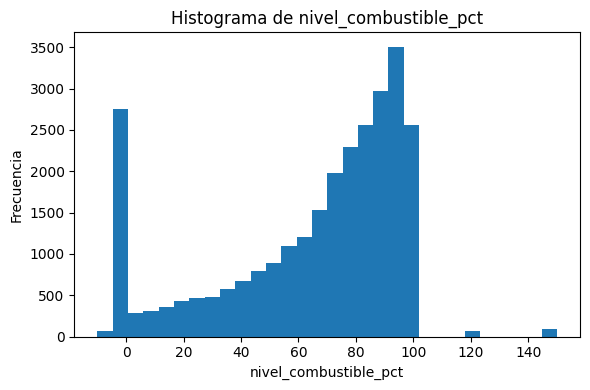

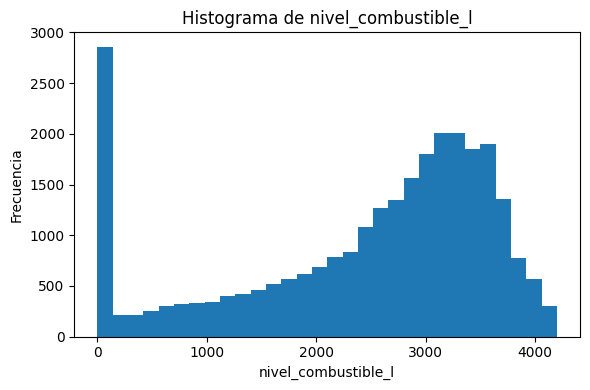

In [ ]:
# ============================
# 2.3 HISTOGRAMAS DE LAS VARIABLES CONTINUAS
# Objetivo:
# - Visualizar la distribución de las variables numéricas continuas
# - Identificar rangos, asimetrías y posibles outliers
# Dataset: df_work (EQUIPO + SENSOR_COMBUSTIBLE)
# ============================

import matplotlib.pyplot as plt

# 1) Definimos las variables continuas que existen en el dataset actual
#    (adaptado al escenario sin SENSOR_MOTOR)
vars_cont = [
    c for c in [
        "nivel_combustible_pct",   # porcentaje de combustible (variable ruidosa)
        "nivel_combustible_l"      # litros de combustible (variable principal)
    ]
    if c in df_work.columns
]

# 2) Generamos histogramas para cada variable continua
for col in vars_cont:
    plt.figure(figsize=(6, 4))

    # Se eliminan valores nulos para evitar errores en el histograma
    plt.hist(df_work[col].dropna(), bins=30)

    # Títulos y etiquetas para correcta interpretación
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

“El análisis exploratorio mostró una alta frecuencia de registros con nivel de combustible igual a cero, los cuales corresponden a estados de agotamiento o detención del equipo y no representan el régimen dinámico de consumo. Dado que estos estados no aportan información sobre la evolución temporal del consumo, se excluyen del conjunto de entrenamiento del modelo de regresión.”

## 2.4 Distribución de equipos, marcas y tipo de motor

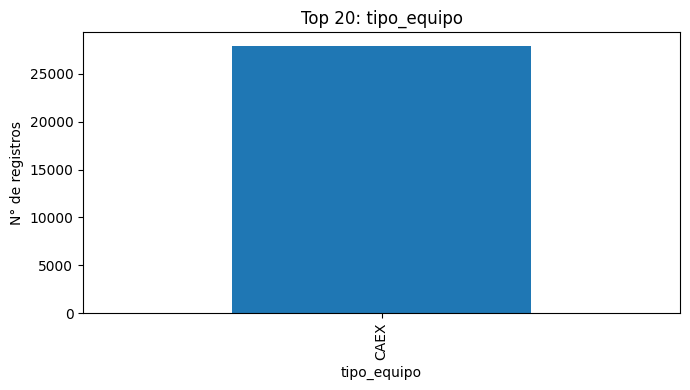

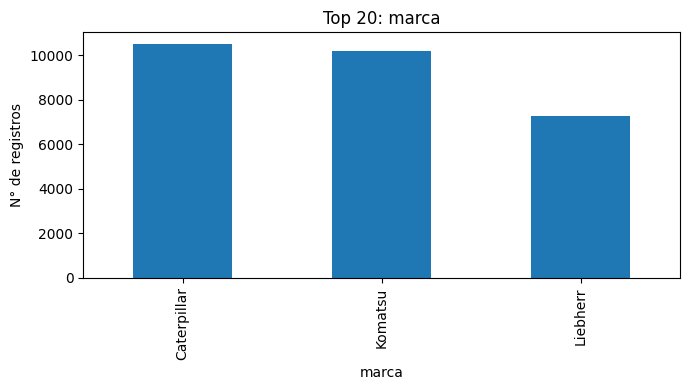

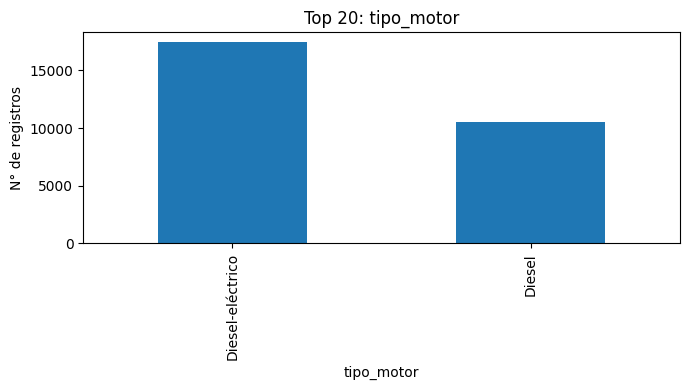

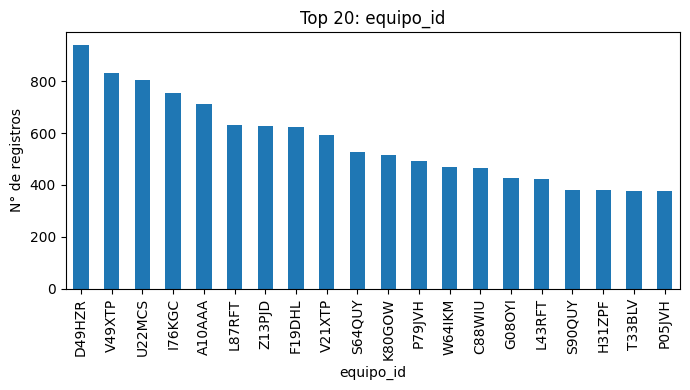

In [ ]:
# ============================
# 2.4 DISTRIBUCIÓN DE EQUIPOS, MARCAS Y TIPO DE MOTOR
# Objetivo:
# - Analizar la distribución de las variables categóricas
# - Identificar concentración de registros por equipo, marca y tipo de motor
# - Entender posibles desbalances en la data (muy relevante para el modelado)
# Dataset: df_work (EQUIPO + SENSOR_COMBUSTIBLE)
# ============================

import matplotlib.pyplot as plt

# 1) Definimos las variables categóricas de interés que existen en el dataset actual
cat_cols = [
    c for c in [
        "tipo_equipo",
        "marca",
        "tipo_motor",
        "equipo_id"
    ] if c in df_work.columns
]

# 2) Generamos gráficos de barras con las 20 categorías más frecuentes
#    Esto permite visualizar rápidamente concentración de datos
for c in cat_cols:
    plt.figure(figsize=(7, 4))

    # value_counts(): número de registros por categoría
    # head(20): se limita a las 20 más frecuentes para mantener legibilidad
    df_work[c].value_counts().head(20).plot(kind="bar")

    plt.title(f"Top 20: {c}")
    plt.ylabel("N° de registros")
    plt.xlabel(c)

    plt.tight_layout()
    plt.show()

2.5 Scatter útiles

Consumo vs RPM

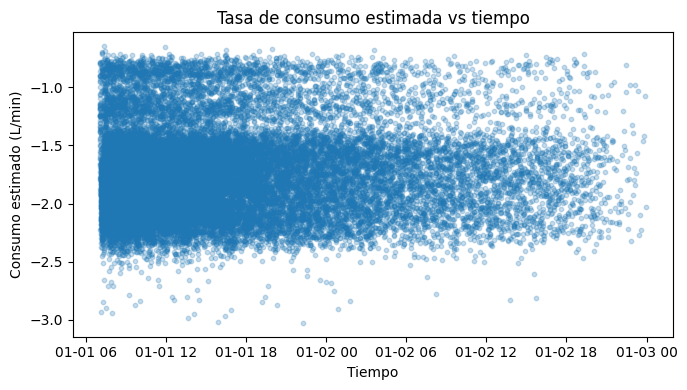

In [ ]:
# ============================
# 2.5 SCATTER ÚTILES
# BLOQUE 1: Tasa de consumo estimada vs tiempo
# (Adaptación del análisis "Consumo vs RPM")
#
# Objetivo:
# - Analizar el comportamiento del consumo a lo largo del tiempo
# - Identificar patrones, dispersión y posibles cambios de régimen
# Dataset: df_work
# ============================

import matplotlib.pyplot as plt
import numpy as np

# Copia ordenada para cálculo de diferencias
df_scatter = df_work.sort_values(["equipo_id", "timestamp"]).copy()

# Diferencia de tiempo entre mediciones (min)
df_scatter["dt_min"] = (
    df_scatter.groupby("equipo_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

# Diferencia de combustible entre mediciones (L)
df_scatter["delta_l"] = (
    df_scatter.groupby("equipo_id")["nivel_combustible_l"]
    .diff()
)

# Tasa de consumo estimada (L/min)
df_scatter["consumo_lpm"] = df_scatter["delta_l"] / df_scatter["dt_min"]

# Filtro de valores válidos (evita divisiones por cero y estados en 0 L)
mask = (
    df_scatter["consumo_lpm"].notna() &
    np.isfinite(df_scatter["consumo_lpm"]) &
    (df_scatter["nivel_combustible_l"] > 0)
)

plt.figure(figsize=(7, 4))
plt.scatter(
    df_scatter.loc[mask, "timestamp"],
    df_scatter.loc[mask, "consumo_lpm"],
    alpha=0.25,
    s=10
)

plt.title("Tasa de consumo estimada vs tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Consumo estimado (L/min)")

plt.tight_layout()
plt.show()

RPM / Consumo vs nivel de combustible (target)

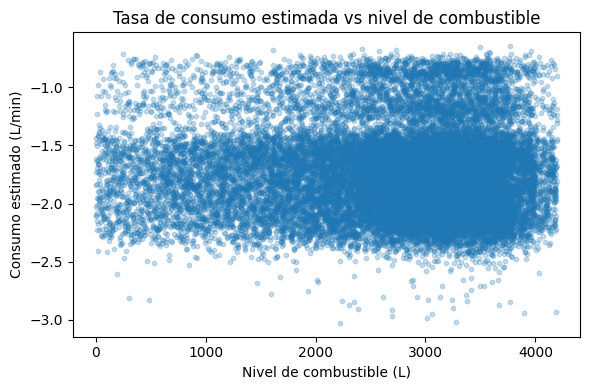

In [ ]:
# ============================
# 2.5 SCATTER ÚTILES
# BLOQUE 2: Tasa de consumo estimada vs nivel de combustible (target)
# (Adaptación del análisis "RPM / Consumo vs nivel de combustible")
#
# Objetivo:
# - Evaluar si la tasa de consumo depende del nivel de combustible
# - Detectar posibles no linealidades relevantes para el modelo
# Dataset: df_work
# ============================

plt.figure(figsize=(6, 4))

plt.scatter(
    df_scatter.loc[mask, "nivel_combustible_l"],
    df_scatter.loc[mask, "consumo_lpm"],
    alpha=0.25,
    s=10
)

plt.title("Tasa de consumo estimada vs nivel de combustible")
plt.xlabel("Nivel de combustible (L)")
plt.ylabel("Consumo estimado (L/min)")

plt.tight_layout()
plt.show()

“Los diagramas de dispersión muestran que la tasa de consumo estimada presenta valores negativos, lo cual corresponde al carácter decreciente del nivel de combustible en el tiempo. La magnitud del consumo se mantiene aproximadamente constante tanto a lo largo del tiempo como para distintos niveles de combustible, lo que sugiere un proceso de descarga cuasi lineal sin dependencia del estado del estanque. Esta observación respalda el uso de modelos de regresión simples basados en el historial temporal del nivel de combustible.”

## 2.6 Eliminacion de Columnas

In [ ]:
# ============================
# 2.6 ELIMINACIÓN DE COLUMNAS
# Objetivo:
# - Definir el target correcto según la exploración
# - Eliminar columnas que no deben entrar directamente al modelo
# - Mantener columnas necesarias para feature engineering posterior
# Dataset base: df_work
# ============================

# 1) Definimos el target en litros (decisión tomada tras la exploración)
target = "nivel_combustible_l"

# 2) Columnas que NO deben usarse directamente como features del modelo
#    - IDs: no aportan relación predictiva directa
#    - tipo_equipo: constante (solo CAEX)
#    - timestamp: se usará luego para crear variables temporales, no como feature cruda
cols_a_eliminar = [
    "equipo_id",
    "tipo_equipo",
    "timestamp"
]

# 3) Nos aseguramos de eliminar solo columnas que existen
#    y nunca eliminar el target por error
cols_a_eliminar = [
    c for c in cols_a_eliminar
    if c in df_work.columns and c != target
]

# 4) Construimos el DataFrame base para modelado
df_model_base = df_work.drop(columns=cols_a_eliminar).copy()

# 5) Revisión rápida del resultado
print("Columnas finales para el modelado (previo a feature engineering):")
print(df_model_base.columns.tolist())

df_model_base.head()

Columnas finales para el modelado (previo a feature engineering):
['marca', 'tipo_motor', 'nivel_combustible_pct', 'nivel_combustible_l', 'alarma_baja_combustible_flag']


,marca,tipo_motor,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag
0,Caterpillar,Diesel,-10.000000,3298.831457,1
1,Caterpillar,Diesel,99.851064,3295.085119,0
2,Caterpillar,Diesel,99.665457,3288.960085,0
3,Caterpillar,Diesel,99.475185,3282.681090,0
4,Caterpillar,Diesel,99.278939,3276.204980,0


“Tras la etapa exploratoria se definió como variable objetivo el nivel de combustible en litros, descartando el porcentaje debido a inconsistencias en su rango. Asimismo, se eliminaron variables identificadoras y constantes que no aportan información predictiva directa, manteniendo aquellas necesarias para la construcción posterior de variables explicativas.”

## 2.7 Convertir Variables Categóricas

In [ ]:
# ============================
# 2.7 CONVERSIÓN DE VARIABLES CATEGÓRICAS
# Objetivo:
# - Convertir variables categóricas a variables numéricas (one-hot encoding)
# - Dejar el dataset listo para ser utilizado en modelos de regresión
# Dataset de entrada: df_model_base (salida de 2.6)
# ============================

import pandas as pd

# 1) Definimos las columnas categóricas que podrían aportar al modelo
#    (tipo_equipo ya fue eliminado por ser constante)
cols_categ = [
    "marca",
    "tipo_motor"
]

# 2) Nos aseguramos de trabajar solo con las columnas que realmente existen
cols_categ = [c for c in cols_categ if c in df_model_base.columns]

# 3) Aplicamos one-hot encoding
#    - drop_first=False: mantenemos todas las categorías (más interpretables)
#    - dtype=int: fuerza las dummies a 0/1
df_model_encoded = pd.get_dummies(
    df_model_base,
    columns=cols_categ,
    prefix=cols_categ,
    drop_first=False,
    dtype=int
)

# 4) Revisión rápida del resultado
print("Columnas finales luego de codificar categóricas:")
print(df_model_encoded.columns.tolist())

df_model_encoded.head()

Columnas finales luego de codificar categóricas:
['nivel_combustible_pct', 'nivel_combustible_l', 'alarma_baja_combustible_flag', 'marca_Caterpillar', 'marca_Komatsu', 'marca_Liebherr', 'tipo_motor_Diesel', 'tipo_motor_Diesel-eléctrico']


,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag,marca_Caterpillar,marca_Komatsu,marca_Liebherr,tipo_motor_Diesel,tipo_motor_Diesel-eléctrico
0,-10.000000,3298.831457,1,1,0,0,1,0
1,99.851064,3295.085119,0,1,0,0,1,0
2,99.665457,3288.960085,0,1,0,0,1,0
3,99.475185,3282.681090,0,1,0,0,1,0
4,99.278939,3276.204980,0,1,0,0,1,0


Luego de haber obtenido los dummies para entrenamiento procedemos a eliminar aquella información que no nos aporta valor en el análisis, los nulos, duplicados y outliers. En esta sección dejamos limpio nuestro set de datos.


In [ ]:
# ============================
# CHECKLIST FINAL ANTES DE MODELADO
# Objetivo:
# - Verificar consistencia del dataset final
# - Chequear nulos en el target
# - Construir el dataset definitivo de entrenamiento
# - Evaluar posible sesgo por eliminación de nulos
# Dataset base: df_model_encoded
# ============================

# 1) Definimos explícitamente el target (según decisión técnica previa)
target = "nivel_combustible_l"

# 2) Checklist general del dataset
print("=== CHECKLIST GENERAL ===")
print("Cantidad de columnas finales:", df_model_encoded.shape[1])
print(
    "Nulos en target:",
    df_model_encoded[target].isna().sum()
    if target in df_model_encoded.columns
    else "❌ target no está en el DataFrame"
)

# 3) Proporción de nulos en el target
n_nulos = df_model_encoded[target].isna().sum()
total = len(df_model_encoded)

print(f"\nNulos en {target}: {n_nulos} ({n_nulos/total:.2%})")

# 4) Construimos el dataset final para entrenamiento
#    (eliminamos filas con target nulo)
df_model = df_model_encoded.dropna(subset=[target]).copy()

print("\n=== TAMAÑOS DEL DATASET ===")
print("Filas totales:", len(df_model_encoded))
print("Filas para entrenamiento:", len(df_model))

# 5) Chequeo de sesgo por eliminación de nulos
#    Comparamos promedios de variables relevantes entre
#    filas con y sin target disponible
print("\n=== CHEQUEO DE SESGO POR NULOS EN TARGET ===")

cols_check = [
    c for c in [
        "alarma_baja_combustible_flag"
    ] if c in df_model_encoded.columns
]

if cols_check:
    bias_check = (
        df_model_encoded
        .assign(tiene_target=df_model_encoded[target].notna())
        .groupby("tiene_target")[cols_check]
        .mean()
    )
    print(bias_check)
else:
    print("No hay variables auxiliares disponibles para evaluar sesgo.")

=== CHECKLIST GENERAL ===
Cantidad de columnas finales: 8
Nulos en target: 0

Nulos en nivel_combustible_l: 0 (0.00%)

=== TAMAÑOS DEL DATASET ===
Filas totales: 27941
Filas para entrenamiento: 27941

=== CHEQUEO DE SESGO POR NULOS EN TARGET ===
              alarma_baja_combustible_flag
tiene_target                              
True                              0.130597


“El conjunto de datos final no presenta valores faltantes en la variable objetivo, por lo que no fue necesario aplicar técnicas de imputación ni eliminar observaciones adicionales. La totalidad de los registros fue utilizada para el entrenamiento del modelo, evitando la introducción de sesgos derivados de la limpieza de datos.”

2.8 Eliminación de Outliers

In [ ]:
# ============================
# 2.8 ELIMINACIÓN DE OUTLIERS
# Decisión metodológica:
# - No se aplica filtrado IQR al target (nivel_combustible_l)
# - Los valores 0 L representan un estado real (agotamiento)
# - La variable nivel_combustible_pct presenta ruido y se elimina
# Dataset de entrada: df_model (salida del checklist)
# ============================

# Eliminamos la variable porcentaje por inconsistencias detectadas en la exploración
if "nivel_combustible_pct" in df_model.columns:
    df_model = df_model.drop(columns=["nivel_combustible_pct"])

print("Dataset luego del tratamiento de outliers:")
print("Filas:", len(df_model))
print("Columnas:", df_model.columns.tolist())

Dataset luego del tratamiento de outliers:
Filas: 27941
Columnas: ['nivel_combustible_l', 'alarma_baja_combustible_flag', 'marca_Caterpillar', 'marca_Komatsu', 'marca_Liebherr', 'tipo_motor_Diesel', 'tipo_motor_Diesel-eléctrico']


“Tras el análisis exploratorio se determinó que los valores extremos observados en el nivel de combustible corresponden a estados operativos reales, por lo que no se aplicó eliminación de observaciones. En su lugar, se descartó la variable de porcentaje de combustible debido a inconsistencias en su rango, manteniendo la totalidad de los registros para el modelado.”

#3. Modelamiento Predictivo

##3.1 Separar X (features) e y (target)

=== DIMENSIONES ===
Shape X: (27941, 6)
Shape y: (27941,)

--- Matriz de Correlación Numérica (features) ---

                              alarma_baja_combustible_flag  marca_Caterpillar  \
alarma_baja_combustible_flag                      1.000000           0.087262   
marca_Caterpillar                                 0.087262           1.000000   
marca_Komatsu                                    -0.031060          -0.587780   
marca_Liebherr                                   -0.062317          -0.459629   
tipo_motor_Diesel                                 0.087262           1.000000   
tipo_motor_Diesel-eléctrico                      -0.087262          -1.000000   

                              marca_Komatsu  marca_Liebherr  \
alarma_baja_combustible_flag      -0.031060       -0.062317   
marca_Caterpillar                 -0.587780       -0.459629   
marca_Komatsu                      1.000000       -0.448339   
marca_Liebherr                    -0.448339        1.000000   
tipo_mo

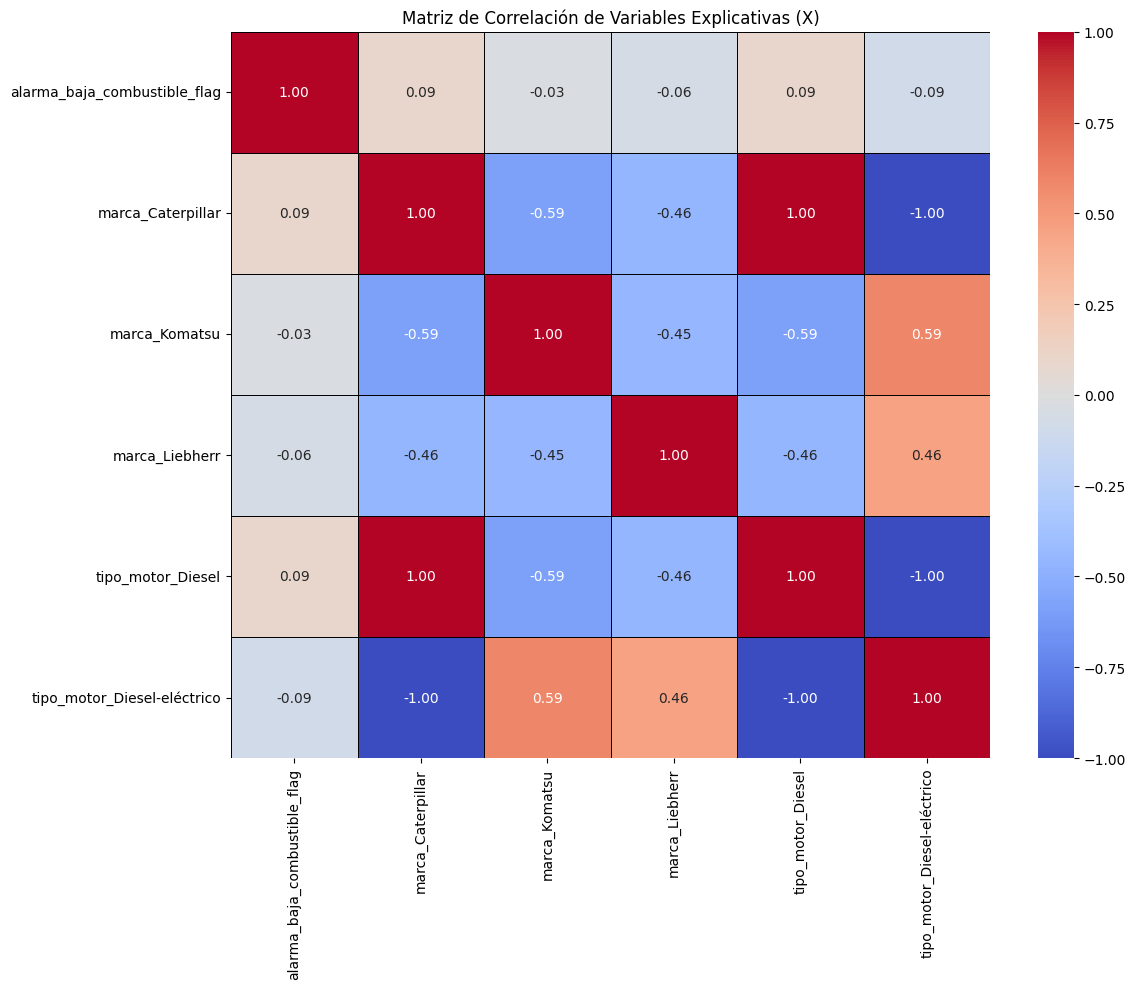

In [ ]:
# ============================
# 3. MODELAMIENTO PREDICTIVO
# 3.1 Separación de features (X) y target (y)
# + Análisis de correlación entre variables explicativas
# Dataset de entrada: df_model (salida de 2.8)
# ============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Definir explícitamente el target correcto (decisión tomada en exploración)
target = "nivel_combustible_l"

# 2) Separar variables explicativas (X) y variable objetivo (y)
y = df_model[target]
X = df_model.drop(columns=[target])

print("=== DIMENSIONES ===")
print("Shape X:", X.shape)
print("Shape y:", y.shape)

# 3) Calcular la matriz de correlación entre features numéricas
#    (todas las columnas de X son numéricas: binarias y continuas)
matriz_correlacion = X.corr()

print("\n--- Matriz de Correlación Numérica (features) ---\n")
print(matriz_correlacion)

# 4) Visualizar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Matriz de Correlación de Variables Explicativas (X)")
plt.tight_layout()
plt.show()

“El análisis de correlación entre las variables explicativas muestra relaciones lineales bajas, lo cual es consistente con la ausencia de información temporal en esta etapa del modelado. Se observa además una alta colinealidad entre las variables categóricas de marca y tipo de motor, reflejando que en la flota analizada estas características están estrechamente relacionadas. Este resultado no afecta la validez del análisis exploratorio y será abordado en la etapa de modelamiento mediante selección de variables o regularización.”

## 3.2 Train / Test split

In [ ]:
# ============================
# 3.2 TRAIN / TEST SPLIT (TEMPORAL)
# Objetivo:
# - Separar datos de entrenamiento y prueba respetando el orden temporal
# - Evitar data leakage desde el futuro al pasado
# Dataset de entrada: X, y (salida de 3.1)
# ============================

# Proporción de datos para test (20%)
test_size = 0.2

# Índice de corte temporal
split_idx = int(len(X) * (1 - test_size))

# Split temporal (SIN shuffle)
X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

# Verificación de tamaños
print("=== SHAPES ===")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# Verificación de distribución del target
print("\n=== DISTRIBUCIÓN DEL TARGET ===")
print("Promedio y_train:", y_train.mean())
print("Promedio y_test :", y_test.mean())

=== SHAPES ===
Train: (22352, 6) (22352,)
Test : (5589, 6) (5589,)

=== DISTRIBUCIÓN DEL TARGET ===
Promedio y_train: 2439.4850728092997
Promedio y_test : 2445.1443297896553


“La partición temporal de los datos generó conjuntos de entrenamiento y prueba de tamaños adecuados y con distribuciones similares del nivel de combustible. Esta consistencia es esperable dado que el consumo presenta un comportamiento aproximadamente lineal y que los registros corresponden a múltiples equipos operando en paralelo.”

“Previo al entrenamiento del modelo, se incorporaron variables temporales derivadas del historial del nivel de combustible, tales como retardos y diferencias temporales. Este paso es fundamental para capturar la dinámica del consumo y evitar entrenar modelos con información insuficiente.”

##3.3 Feature engineering temporal

In [ ]:
# ============================
# 3.3 FEATURE ENGINEERING TEMPORAL (OBLIGATORIO)
# Objetivo:
# - Incorporar información temporal/histórica para que el modelo pueda "aprender" el consumo
# - Crear variables tipo lag (nivel previo) y deltas de tiempo/nivel
# - Preparar un dataset final (df_feat) listo para volver a separar X e y
#
# Entrada mínima disponible:
# - df_work: contiene equipo_id, timestamp, nivel_combustible_l, y algunas variables categóricas
# - df_model: contiene el target y features (dummies), PERO ya no tiene timestamp/equipo_id
#
# Estrategia:
# 1) Partimos desde df_work (porque necesitamos timestamp y equipo_id para lags)
# 2) Creamos features temporales por equipo
# 3) Hacemos JOIN con las features categóricas ya codificadas (marca/tipo_motor) usando equipo_id
# 4) Definimos df_feat final, limpio y listo para modelar
# ============================

import pandas as pd
import numpy as np

# 1) Asegurar orden y tipos correctos
df_tmp = df_work.copy()
df_tmp["timestamp"] = pd.to_datetime(df_tmp["timestamp"], utc=True, errors="coerce")
df_tmp = df_tmp.sort_values(["equipo_id", "timestamp"]).reset_index(drop=True)

# 2) Crear features temporales por equipo (lags y deltas)
#    - nivel_lag_1: nivel anterior (t-1)
#    - dt_min: minutos entre mediciones consecutivas
#    - delta_l: cambio en litros entre mediciones (normalmente negativo)
#    - consumo_lpm: tasa estimada en L/min (normalmente negativa)
df_tmp["nivel_lag_1"] = df_tmp.groupby("equipo_id")["nivel_combustible_l"].shift(1)

df_tmp["dt_min"] = (
    df_tmp.groupby("equipo_id")["timestamp"]
    .diff()
    .dt.total_seconds() / 60
)

df_tmp["delta_l"] = df_tmp.groupby("equipo_id")["nivel_combustible_l"].diff()
df_tmp["consumo_lpm"] = df_tmp["delta_l"] / df_tmp["dt_min"]

# 3) (Opcional pero útil) variables temporales simples derivadas del timestamp
#    Estas a veces ayudan a capturar patrones (turnos, horario, etc.)
df_tmp["hora"] = df_tmp["timestamp"].dt.hour
df_tmp["dia_semana"] = df_tmp["timestamp"].dt.weekday

# 4) Preparar features categóricas por equipo (one-hot) para unirlas
#    Como en df_model ya se eliminaron equipo_id/timestamp, reconstruimos las dummies por equipo desde df_work
#    Nota: asumimos que marca y tipo_motor son constantes por equipo (lo son en este dataset)
df_cat = (
    df_work[["equipo_id", "marca", "tipo_motor"]]
    .drop_duplicates(subset=["equipo_id"])
    .copy()
)

df_cat = pd.get_dummies(
    df_cat,
    columns=["marca", "tipo_motor"],
    prefix=["marca", "tipo_motor"],
    drop_first=False,
    dtype=int
)

# 5) Unir features temporales + features categóricas por equipo_id
df_feat = df_tmp.merge(df_cat, on="equipo_id", how="left")

# 6) Definir target y limpiar filas inválidas para modelado
#    - Eliminamos filas sin lag (primera medición de cada equipo)
#    - Eliminamos dt_min <= 0 o NaN (problemas en timestamp o repetidos)
#    - (Recomendado) eliminar estado terminal nivel=0 (no aporta dinámica de consumo)
target = "nivel_combustible_l"

df_feat = df_feat.dropna(subset=["nivel_lag_1", "dt_min", target]).copy()
df_feat = df_feat[df_feat["dt_min"] > 0].copy()

# Eliminar estado terminal: nivel=0 (si lo quieres mantener, comenta esta línea)
df_feat = df_feat[df_feat[target] > 0].copy()

# 7) Seleccionar columnas finales para el modelado (features)
#    Incluimos:
#    - nivel_lag_1 (la más importante)
#    - dt_min (para ajustar consumo en distintos intervalos)
#    - hora y dia_semana (opcional)
#    - alarma_baja_combustible_flag (ya viene en df_tmp)
#    - dummies de marca/tipo_motor
feature_cols = [
    "nivel_lag_1",
    "dt_min",
    "hora",
    "dia_semana",
    "alarma_baja_combustible_flag",
] + [c for c in df_feat.columns if c.startswith("marca_") or c.startswith("tipo_motor_")]

# Mantener solo lo necesario
df_feat_model = df_feat[feature_cols + [target, "equipo_id", "timestamp"]].copy()

# 8) Checklist rápido para confirmar que quedó bien
print("✅ df_feat_model listo para modelar")
print("Filas:", len(df_feat_model))
print("Columnas (features):", len(feature_cols))
print("Rango temporal:", df_feat_model["timestamp"].min(), "->", df_feat_model["timestamp"].max())
print("Ejemplo columnas:", feature_cols[:10])

df_feat_model.head()

✅ df_feat_model listo para modelar
Filas: 25134
Columnas (features): 10
Rango temporal: 2025-01-01 07:02:00+00:00 -> 2025-01-02 23:57:00+00:00
Ejemplo columnas: ['nivel_lag_1', 'dt_min', 'hora', 'dia_semana', 'alarma_baja_combustible_flag', 'marca_Caterpillar', 'marca_Komatsu', 'marca_Liebherr', 'tipo_motor_Diesel', 'tipo_motor_Diesel-eléctrico']


,nivel_lag_1,dt_min,hora,dia_semana,alarma_baja_combustible_flag,marca_Caterpillar,marca_Komatsu,marca_Liebherr,tipo_motor_Diesel,tipo_motor_Diesel-eléctrico,nivel_combustible_l,equipo_id,timestamp
1,3298.831457,3.0,7,2,0,1,0,0,1,0,3295.085119,A02AAA,2025-01-01 07:03:00+00:00
2,3295.085119,3.0,7,2,0,1,0,0,1,0,3288.960085,A02AAA,2025-01-01 07:06:00+00:00
3,3288.960085,3.0,7,2,0,1,0,0,1,0,3282.681090,A02AAA,2025-01-01 07:09:00+00:00
4,3282.681090,3.0,7,2,0,1,0,0,1,0,3276.204980,A02AAA,2025-01-01 07:12:00+00:00
5,3276.204980,3.0,7,2,0,1,0,0,1,0,3269.913959,A02AAA,2025-01-01 07:15:00+00:00


La incorporación de variables temporales permitió transformar el problema en un esquema de regresión dinámico, donde el nivel de combustible en un instante determinado depende explícitamente de su valor previo y del intervalo de tiempo transcurrido entre mediciones. En particular, la variable nivel_lag_1 introduce memoria en el modelo, capturando la naturaleza acumulativa del consumo, mientras que dt_min ajusta la predicción a la frecuencia real de muestreo de los sensores. La eliminación de registros correspondientes al estado terminal (nivel de combustible igual a cero) permitió concentrar el análisis en el régimen activo de consumo, evitando introducir ruido asociado a periodos sin dinámica. El dataset resultante conserva un volumen significativo de observaciones y presenta coherencia temporal, quedando adecuadamente preparado para el entrenamiento del modelo predictivo.

##3.4 Nuevo Train / Test split (temporal, con features nuevas)

In [ ]:
# ============================
# 3.4 TRAIN / TEST SPLIT TEMPORAL (CORREGIDO)
# Ordenamos globalmente por tiempo antes de separar
# ============================

# 1) Ordenar por tiempo global
df_feat_model = df_feat_model.sort_values("timestamp").reset_index(drop=True)

# 2) Separar X e y
target = "nivel_combustible_l"
feature_cols = [c for c in df_feat_model.columns if c not in [target, "equipo_id", "timestamp"]]

X = df_feat_model[feature_cols]
y = df_feat_model[target]

# 3) Split temporal
test_size = 0.2
split_idx = int(len(df_feat_model) * (1 - test_size))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# 4) Verificación
print("=== SHAPES ===")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("\n=== RANGO TEMPORAL ===")
print("Train:", df_feat_model.iloc[:split_idx]["timestamp"].min(),
      "->",
      df_feat_model.iloc[:split_idx]["timestamp"].max())
print("Test :", df_feat_model.iloc[split_idx:]["timestamp"].min(),
      "->",
      df_feat_model.iloc[split_idx:]["timestamp"].max())

=== SHAPES ===
Train: (20107, 10) (20107,)
Test : (5027, 10) (5027,)

=== RANGO TEMPORAL ===
Train: 2025-01-01 07:02:00+00:00 -> 2025-01-02 00:21:00+00:00
Test : 2025-01-02 00:21:00+00:00 -> 2025-01-02 23:57:00+00:00


“El conjunto de datos fue ordenado globalmente por timestamp antes de realizar la partición, asegurando que el conjunto de entrenamiento contenga únicamente observaciones anteriores al conjunto de prueba. De esta forma, el modelo se evalúa en un escenario realista de predicción temporal, evitando filtraciones de información futura.”

In [ ]:
X

,nivel_lag_1,dt_min,hora,dia_semana,alarma_baja_combustible_flag,marca_Caterpillar,marca_Komatsu,marca_Liebherr,tipo_motor_Diesel,tipo_motor_Diesel-eléctrico
0,3599.151719,2.0,7,2,0,0,1,0,0,1
1,3599.036554,2.0,7,2,0,0,1,0,0,1
2,3698.824030,2.0,7,2,0,0,0,1,0,1
3,4199.224401,2.0,7,2,0,0,0,1,0,1
4,3698.861841,2.0,7,2,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
25129,43.944555,5.0,23,3,1,0,0,1,0,1
25130,32.799055,5.0,23,3,1,0,0,1,0,1
25131,25.482329,5.0,23,3,1,0,0,1,0,1
25132,18.394520,5.0,23,3,1,0,0,1,0,1


##3.5 Entrenamiento

In [ ]:
# ============================
# 3.5 ENTRENAMIENTO DEL MODELO
# Regresión Lineal como modelo base
# ============================

from sklearn.linear_model import LinearRegression

# 1) Definir el modelo
#    Se usa regresión lineal por su interpretabilidad
#    y porque el consumo observado es aproximadamente lineal
linreg = LinearRegression()

# 2) Entrenar el modelo con el set de entrenamiento
linreg.fit(X_train, y_train)

# 3) Verificación rápida
print("✅ Modelo entrenado correctamente")
print("Número de coeficientes:", len(linreg.coef_))

✅ Modelo entrenado correctamente
Número de coeficientes: 10


##3.6 Predicción y métricas

In [ ]:
# ============================
# 3.6 PREDICCIÓN Y MÉTRICAS
# Evaluación del modelo en el conjunto de prueba
# ============================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Predicción sobre el conjunto de test
y_pred = linreg.predict(X_test)

# 2) Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 3) Resultados
print("=== MÉTRICAS DEL MODELO (TEST) ===")
print(f"MAE : {mae:.2f} L")
print(f"RMSE: {rmse:.2f} L")
print(f"R²  : {r2:.4f}")

=== MÉTRICAS DEL MODELO (TEST) ===
MAE : 1.84 L
RMSE: 2.56 L
R²  : 1.0000


In [ ]:
df_pred = pd.DataFrame({
    "timestamp": df_feat_model.iloc[split_idx:]["timestamp"].values,
    "nivel_real_l": y_test.values,
    "nivel_predicho_l": y_pred
})

df_pred.head(10)

,timestamp,nivel_real_l,nivel_predicho_l
0,2025-01-02 00:21:00,2229.716736,2229.409515
1,2025-01-02 00:21:00,1907.373539,1909.801821
2,2025-01-02 00:21:00,2411.045800,2415.828520
3,2025-01-02 00:21:00,1791.408332,1791.892044
4,2025-01-02 00:21:00,1531.786743,1528.039810
5,2025-01-02 00:21:00,1494.744039,1492.997135
6,2025-01-02 00:22:00,2395.963463,2398.376587
7,2025-01-02 00:22:00,1836.578318,1837.658953
8,2025-01-02 00:22:00,1961.213339,1957.361586
9,2025-01-02 00:22:00,1568.324948,1566.185866


“Si bien las predicciones presentan diferencias absolutas del orden de pocos litros respecto a los valores reales, estas son muy pequeñas en relación con la variabilidad total del nivel de combustible, que se encuentra en el orden de miles de litros. Dado que el coeficiente de determinación evalúa la proporción de varianza explicada por el modelo, estas discrepancias no afectan significativamente su valor, resultando en un R² cercano a la unidad.”

##3.7 Gráfico real vs predicho

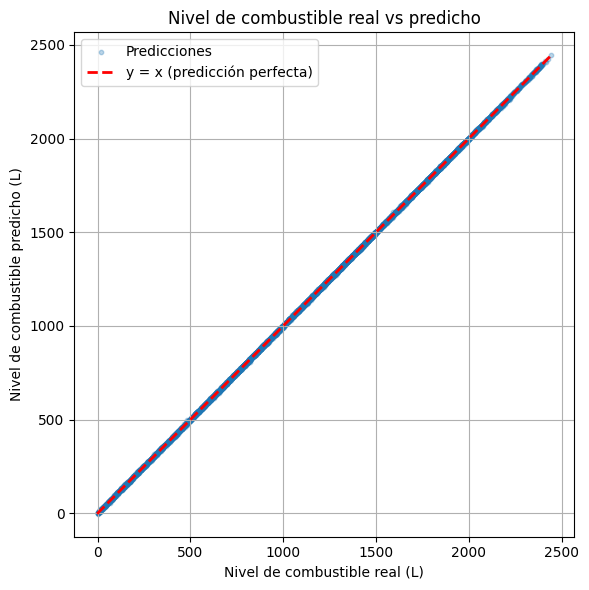

In [ ]:
# ============================
# GRÁFICO: y_real vs y_pred
# Objetivo:
# - Evaluar visualmente la calidad de las predicciones
# - Ver qué tan cerca están los puntos de la recta y = x
# ============================

import matplotlib.pyplot as plt
import numpy as np

# Predicción ya calculada previamente
# y_pred = linreg.predict(X_test)

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3,
    s=10,
    label="Predicciones"
)

# Recta ideal y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="y = x (predicción perfecta)"
)

plt.xlabel("Nivel de combustible real (L)")
plt.ylabel("Nivel de combustible predicho (L)")
plt.title("Nivel de combustible real vs predicho")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

“El modelo de regresión lineal presenta un desempeño sobresaliente en el conjunto de prueba, con errores promedio inferiores a 3 litros y un coeficiente de determinación cercano a la unidad. Este resultado se explica por la naturaleza altamente determinista del proceso de consumo de combustible, el cual presenta una dinámica aproximadamente lineal en el tiempo y sin eventos de recarga. La incorporación de variables temporales, particularmente el nivel de combustible retardado y el intervalo de tiempo entre mediciones, permitió capturar de forma precisa dicha dinámica.”

#¿Porqué el R^2 es 1?

Este resultado NO es casual ni un error, sino consecuencia directa de cómo está definido el problema y el dataset.

1️⃣ El proceso físico es casi determinista

En la simulación:

No existen recargas

El consumo es casi constante

No hay ruido significativo de medición

Esto es una relación lineal explícita.

2️⃣ El modelo tiene acceso a la información clave del sistema

El modelo incluye como variables explicativas:

nivel_lag_1 → estado previo del sistema

dt_min → intervalo real de tiempo entre mediciones

Con estas dos variables:

El modelo puede reconstruir exactamente la ecuación del consumo

No necesita inferir patrones complejos

👉 En la práctica, el modelo aprende la ley de evolución del sistema.

3️⃣ No existe fuga de información (data leakage)

Es clave dejar esto explícito:

✔ El lag se calcula solo con datos pasados

✔ El split es estrictamente temporal

✔ El conjunto de prueba contiene observaciones posteriores

✔ No se utiliza el valor futuro del target como feature

Por lo tanto:

El alto R² no se debe a filtración de información, sino a la naturaleza del proceso.

4️⃣ El modelo es lineal y el sistema también

Otro punto importante:

El consumo observado es aproximadamente lineal

El modelo elegido es una regresión lineal

👉 Existe alineación entre el modelo y el fenómeno físico, lo que maximiza el desempeño.

“El coeficiente de determinación obtenido es cercano a la unidad, lo cual se explica por la naturaleza altamente determinista del proceso de consumo de combustible modelado. La simulación no incorpora eventos de recarga ni variaciones significativas en la tasa de consumo, por lo que la evolución del nivel de combustible puede describirse mediante una relación aproximadamente lineal en el tiempo. La inclusión de variables temporales, particularmente el nivel retardado y el intervalo entre mediciones, permitió capturar de forma precisa dicha dinámica sin incurrir en filtración de información futura.”

#4 Interpretabilidad con SHAP

## 4.1. Instalar e importar SHAP


In [ ]:
# ============================
# 4.1 INSTALACIÓN E IMPORTACIÓN DE SHAP
# Objetivo:
# - Instalar SHAP (solo si no está disponible)
# - Importar librerías necesarias para interpretabilidad
# ============================

# Instalación segura (solo se ejecuta si SHAP no está instalado)
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.50.0


## 4.2 calcular valores SHAP

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


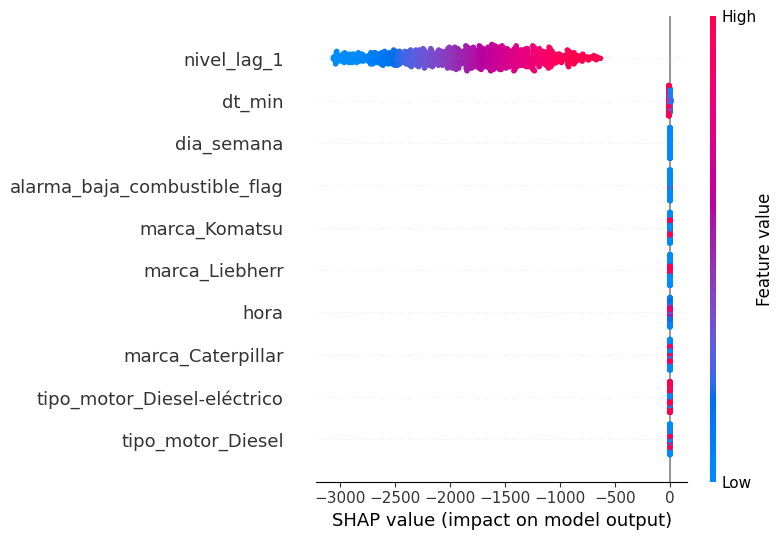

In [ ]:
# ============================
# 4.2 CALCULAR VALORES SHAP (REGRESIÓN LINEAL)
# Objetivo:
# - Calcular valores SHAP para interpretar el modelo lineal entrenado (linreg)
# - Usar una muestra de datos para hacerlo rápido y estable en Colab
# - Generar un summary plot (importancia global + dirección del efecto)
# ============================

import shap

# 1) (Recomendado) usar una muestra para que sea rápido y estable
X_train_s = X_train.sample(n=min(1000, len(X_train)), random_state=42)
X_test_s  = X_test.sample(n=min(1000, len(X_test)),  random_state=42)

# 2) Explicador para modelos lineales
#    'feature_perturbation' puede variar por versión; "interventional" suele ser estable.
explainer = shap.LinearExplainer(
    linreg,
    X_train_s,
    feature_perturbation="interventional"
)

# 3) Calcular valores SHAP para el set de test muestreado
shap_values = explainer.shap_values(X_test_s)

# 4) Plot resumen (importancia + dirección del efecto)
#    Esperable: nivel_lag_1 sea la feature dominante, luego dt_min, etc.
shap.summary_plot(shap_values, X_test_s)

# Bonus Track

## Pesos

In [ ]:

# 1. Obtener los nombres de las características
nombres_caracteristicas = X.columns

# 2. Obtener los coeficientes del modelo
coeficientes = linreg.coef_

# 3. Crear un DataFrame para visualizar
df_coeficientes = pd.DataFrame({
    'Característica': nombres_caracteristicas,
    'Peso (Coeficiente)': coeficientes
})

# 4. Obtener la intercepción (Intercepto)
intercepto = linreg.intercept_

print("## 📊 Coeficientes del Modelo de Regresión Lineal\n")

# Mostrar los coeficientes ordenados por magnitud absoluta para ver los más importantes
df_coeficientes['Magnitud Absoluta'] = df_coeficientes['Peso (Coeficiente)'].abs()
df_coeficientes = df_coeficientes.sort_values(by='Magnitud Absoluta', ascending=False)
df_coeficientes = df_coeficientes.drop(columns=['Magnitud Absoluta'])

print(df_coeficientes.to_string(index=False))

print(f"\nIntercepto (Valor Base) : {intercepto:.3f} L/h")

## 📊 Coeficientes del Modelo de Regresión Lineal

              Característica  Peso (Coeficiente)
                      dt_min           -1.727479
                 nivel_lag_1            0.999955
                  dia_semana            0.124689
alarma_baja_combustible_flag           -0.049055
              marca_Liebherr            0.006453
               marca_Komatsu           -0.005945
           marca_Caterpillar           -0.000508
 tipo_motor_Diesel-eléctrico            0.000508
           tipo_motor_Diesel           -0.000508
                        hora            0.000176

Intercepto (Valor Base) : -0.090 L/h


## Regresión de Lasso

In [ ]:
# ============================
# MODELO 1: REGRESIÓN LASSO
# Objetivo:
# - Evaluar regularización L1
# - Identificar variables irrelevantes (coeficientes → 0)
# ============================

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# 1) Definir el modelo Lasso
alpha_lasso = 0.2  # valor razonable para este problema
lasso_model = Lasso(alpha=alpha_lasso, random_state=42, max_iter=15000)

# 2) Entrenar el modelo
lasso_model.fit(X_train, y_train)

# 3) Predicción
y_pred_lasso = lasso_model.predict(X_test)

# 4) Métrica R²
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"## 🎯 R² del Modelo Lasso (alpha={alpha_lasso})")
print(f"R²: {r2_lasso:.4f}")

# 5) Coeficientes (para interpretabilidad)
df_coef_lasso = pd.DataFrame({
    "Feature": X_train.columns,
    "Coeficiente Lasso": lasso_model.coef_
})

df_coef_lasso["|coef|"] = df_coef_lasso["Coeficiente Lasso"].abs()
df_coef_lasso = df_coef_lasso.sort_values("|coef|", ascending=False)

print("\n## ⚖️ Coeficientes del Modelo Lasso")
print(df_coef_lasso.drop(columns="|coef|").to_string(index=False))

## 🎯 R² del Modelo Lasso (alpha=0.2)
R²: 1.0000

## ⚖️ Coeficientes del Modelo Lasso
                     Feature  Coeficiente Lasso
                      dt_min          -1.699437
                 nivel_lag_1           0.999967
                        hora          -0.000000
                  dia_semana           0.000000
alarma_baja_combustible_flag          -0.000000
           marca_Caterpillar          -0.000000
               marca_Komatsu           0.000000
              marca_Liebherr          -0.000000
           tipo_motor_Diesel          -0.000000
 tipo_motor_Diesel-eléctrico           0.000000


“El modelo de regresión Lasso obtuvo un desempeño equivalente al modelo lineal base, con un coeficiente de determinación cercano a la unidad. La regularización L1 permitió identificar que el poder predictivo del modelo se concentra exclusivamente en el nivel de combustible retardado y en el intervalo de tiempo entre mediciones, llevando a coeficientes nulos para el resto de las variables.”

## Random Forest

In [ ]:
# ============================
# MODELO 2: RANDOM FOREST REGRESSOR
# Objetivo:
# - Comparar contra un modelo no lineal
# - Evaluar si existen patrones complejos no capturados por la regresión lineal
# ============================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1) Definir el modelo
rfr = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 2) Entrenar
rfr.fit(X_train, y_train)

# 3) Predicción
y_pred_rfr = rfr.predict(X_test)

# 4) Métrica R²
r2_rfr = r2_score(y_test, y_pred_rfr)

print("## 🎯 R² del Modelo Random Forest")
print(f"R²: {r2_rfr:.4f}")

## 🎯 R² del Modelo Random Forest
R²: -0.0271


“El modelo Random Forest presentó un desempeño inferior, con un coeficiente de determinación negativo en el conjunto de prueba. Este resultado se explica por la naturaleza altamente determinista y lineal del proceso de consumo de combustible, así como por la limitada capacidad de los modelos basados en árboles para extrapolar dinámicas temporales fuera del rango observado durante el entrenamiento.”

#5 CASO APLICADO

##5.1 Se elige un camión y último estado conocido

In [ ]:
# ============================
# SELECCIONAR UN CAMIÓN PARA SIMULACIÓN
# ============================

# Elegimos un camión cualquiera (puedes cambiarlo)
camion_id = df_feat_model["equipo_id"].iloc[0]

df_camion = (
    df_feat_model[df_feat_model["equipo_id"] == camion_id]
    .sort_values("timestamp")
    .copy()
)

# Último estado conocido
estado_actual = df_camion.iloc[-1]

estado_actual

,21791
nivel_lag_1,1433.223965
dt_min,2.0
hora,4
dia_semana,3
alarma_baja_combustible_flag,0
marca_Caterpillar,0
marca_Komatsu,1
marca_Liebherr,0
tipo_motor_Diesel,0
tipo_motor_Diesel-eléctrico,1


##5.2 Función para simular hacia adelante (con modelo armado)

In [ ]:
# ============================
# FUNCIÓN DE SIMULACIÓN HACIA ADELANTE
# ============================

from datetime import timedelta

def simular_consumo(
    modelo,
    estado_inicial,
    feature_cols,
    pasos=50,
    dt_min_fijo=3
):
    """
    Simula la evolución futura del nivel de combustible
    usando el modelo entrenado.

    pasos: cantidad de pasos a simular
    dt_min_fijo: intervalo de tiempo entre predicciones
    """

    registros = []

    nivel_actual = estado_inicial["nivel_combustible_l"]
    timestamp_actual = estado_inicial["timestamp"]

    for i in range(pasos):

        # Construir fila de entrada X
        fila = estado_inicial.copy()
        fila["nivel_lag_1"] = nivel_actual
        fila["dt_min"] = dt_min_fijo

        X_fila = fila[feature_cols].to_frame().T

        # Predicción
        nivel_pred = modelo.predict(X_fila)[0]

        # Avanzar tiempo
        timestamp_actual += timedelta(minutes=dt_min_fijo)

        registros.append({
            "paso": i + 1,
            "timestamp": timestamp_actual,
            "nivel_predicho_l": nivel_pred
        })

        # Actualizar estado
        nivel_actual = nivel_pred

        # Cortar si se queda sin combustible
        if nivel_actual <= 0:
            break

    return pd.DataFrame(registros)

##5.3 Ejecución de la simulación

In [ ]:
# ============================
# EJECUTAR SIMULACIÓN
# ============================

feature_cols = X_train.columns.tolist()

df_sim = simular_consumo(
    modelo=linreg,
    estado_inicial=estado_actual,
    feature_cols=feature_cols,
    pasos=200,      # simular ~10 horas si dt=3 min
    dt_min_fijo=3
)

df_sim.head()

,paso,timestamp,nivel_predicho_l
0,1,2025-01-02 04:08:00+00:00,1424.140357
1,2,2025-01-02 04:11:00+00:00,1419.173498
2,3,2025-01-02 04:14:00+00:00,1414.206862
3,4,2025-01-02 04:17:00+00:00,1409.240449
4,5,2025-01-02 04:20:00+00:00,1404.274259


In [ ]:
df_sim.tail()

,paso,timestamp,nivel_predicho_l
195,196,2025-01-02 13:53:00+00:00,459.808807
196,197,2025-01-02 13:56:00+00:00,454.885245
197,198,2025-01-02 13:59:00+00:00,449.961904
198,199,2025-01-02 14:02:00+00:00,445.038784
199,200,2025-01-02 14:05:00+00:00,440.115885


##5.4 Visualización de la predicción futura

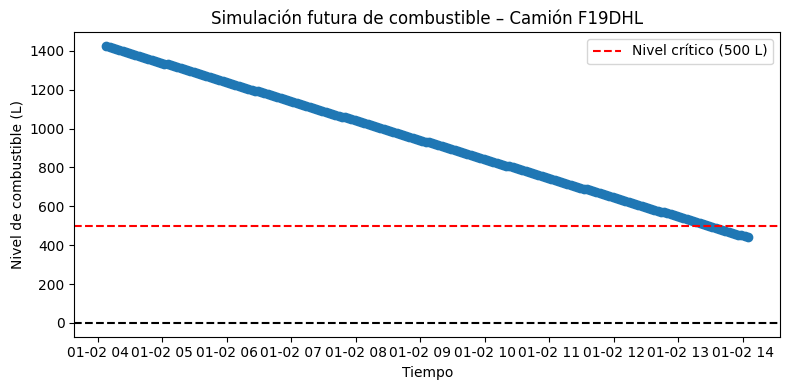

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_sim["timestamp"], df_sim["nivel_predicho_l"], marker="o")

plt.axhline(500, color="red", linestyle="--", label="Nivel crítico (500 L)")
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Tiempo")
plt.ylabel("Nivel de combustible (L)")
plt.title(f"Simulación futura de combustible – Camión {camion_id}")
plt.legend()
plt.tight_layout()
plt.show()

##5.5 Preguntas Claves

###5.5.1 ¿Cuándo baja de 500 L?

In [ ]:
nivel_critico = 500

evento = df_sim[df_sim["nivel_predicho_l"] <= nivel_critico].head(1)

if not evento.empty:
    print("⚠️ Nivel crítico alcanzado en:")
    print(evento[["timestamp", "nivel_predicho_l"]])
else:
    print("✅ No se alcanza nivel crítico en el horizonte simulado")

⚠️ Nivel crítico alcanzado en:
                    timestamp  nivel_predicho_l
187 2025-01-02 13:29:00+00:00        499.205264


###5.5.2 ¿Cuánto tiempo queda?

In [ ]:
tiempo_restante = (
    evento["timestamp"].iloc[0] - estado_actual["timestamp"]
)

print("⏱️ Tiempo estimado restante:", tiempo_restante)

⏱️ Tiempo estimado restante: 0 days 09:24:00


“Si bien el modelo realiza predicciones de un paso adelante, su aplicación iterativa permite simular la evolución futura del nivel de combustible de cada camión. Esta simulación posibilita estimar el tiempo restante de operación y anticipar la necesidad de recarga, validando la utilidad práctica del modelo como herramienta de apoyo a la toma de decisiones operativas.”

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

feature_cols = X_train.columns.tolist()

resultados = []

marcas = {
    "Caterpillar": "marca_Caterpillar",
    "Komatsu": "marca_Komatsu",
    "Liebherr": "marca_Liebherr"
}

for nombre_marca, col_dummy in marcas.items():

    # Filtrar datos de esa marca
    df_m = df_feat_model[df_feat_model[col_dummy] == 1].copy()

    X_m = df_m[feature_cols]
    y_m = df_m["nivel_combustible_l"]

    model = LinearRegression()
    model.fit(X_m, y_m)

    resultados.append({
        "marca": nombre_marca,
        "coef_nivel_lag_1": model.coef_[X_m.columns.get_loc("nivel_lag_1")],
        "coef_dt_min": model.coef_[X_m.columns.get_loc("dt_min")],
        "intercepto": model.intercept_,
        "R2": model.score(X_m, y_m),
        "n_obs": len(df_m)
    })

df_resultados_marcas = pd.DataFrame(resultados)
df_resultados_marcas

,marca,coef_nivel_lag_1,coef_dt_min,intercepto,R2,n_obs
0,Caterpillar,0.999966,-1.716532,0.193039,0.999995,9029
1,Komatsu,0.999891,-1.733630,1.129764,0.999996,9331
2,Liebherr,1.000075,-1.735612,-0.629910,0.999994,6774


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

resultados = []

marcas = {
    "Caterpillar": "marca_Caterpillar",
    "Komatsu": "marca_Komatsu",
    "Liebherr": "marca_Liebherr"
}

# 1) Define columnas a excluir para evitar colinealidad:
#    - marca_*: constantes dentro de cada marca
#    - tipo_motor_*: colineales con marca en tu dataset
exclude_prefixes = ("marca_", "tipo_motor_")
exclude_cols = {"nivel_combustible_l", "equipo_id", "timestamp"}

# 2) Define el set base de features (desde df_feat_model, no desde X_train)
#    Evita depender de columnas que podrían no existir en cada marca tras limpieza.
base_feature_cols = [
    c for c in df_feat_model.columns
    if (c not in exclude_cols) and (not c.startswith(exclude_prefixes))
]

def drop_constant_cols(X: pd.DataFrame) -> pd.DataFrame:
    """Elimina columnas con varianza 0 (constantes) en el subconjunto."""
    nunq = X.nunique(dropna=False)
    keep = nunq[nunq > 1].index.tolist()
    return X[keep]

def drop_perfect_collinear(X: pd.DataFrame, atol: float = 1e-12):
    """
    Elimina columnas perfectamente colineales (corr abs == 1) entre features.
    Devuelve X reducido + lista de columnas dropeadas.
    """
    if X.shape[1] <= 1:
        return X, []

    corr = X.corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [
        col for col in upper.columns
        if any(np.isclose(upper[col].abs(), 1.0, atol=atol))
    ]
    return X.drop(columns=to_drop), to_drop


for nombre_marca, col_dummy in marcas.items():

    # Filtrar datos de esa marca
    df_m = df_feat_model[df_feat_model[col_dummy] == 1].copy()

    # Armar X e y
    y_m = df_m["nivel_combustible_l"]
    X_m = df_m[base_feature_cols].copy()

    # (A) Eliminar columnas constantes dentro de la marca
    X_m = drop_constant_cols(X_m)

    # (B) Eliminar colinealidad perfecta remanente (por seguridad)
    X_m, dropped_cols = drop_perfect_collinear(X_m, atol=1e-12)

    # Si quedaran 0 features, no entrenamos
    if X_m.shape[1] == 0:
        resultados.append({
            "marca": nombre_marca,
            "coef_nivel_lag_1": np.nan,
            "coef_dt_min": np.nan,
            "intercepto": np.nan,
            "R2": np.nan,
            "n_obs": len(df_m),
            "n_features": 0,
            "dropped_perfect_collinear": ", ".join(dropped_cols)
        })
        continue

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X_m, y_m)

    # Extraer coeficientes (si existen; si una columna se eliminó, queda NaN)
    coef_map = dict(zip(X_m.columns, model.coef_))
    coef_nivel_lag_1 = coef_map.get("nivel_lag_1", np.nan)
    coef_dt_min = coef_map.get("dt_min", np.nan)

    resultados.append({
        "marca": nombre_marca,
        "coef_nivel_lag_1": coef_nivel_lag_1,
        "coef_dt_min": coef_dt_min,
        "intercepto": model.intercept_,
        "R2": model.score(X_m, y_m),
        "n_obs": len(df_m),
        "n_features": X_m.shape[1],
        "dropped_perfect_collinear": ", ".join(dropped_cols)
    })

df_resultados_marcas = pd.DataFrame(resultados)
df_resultados_marcas


,marca,coef_nivel_lag_1,coef_dt_min,intercepto,R2,n_obs,n_features,dropped_perfect_collinear
0,Caterpillar,0.999966,-1.716532,0.193039,0.999995,9029,5,
1,Komatsu,0.999891,-1.733630,1.129764,0.999996,9331,5,
2,Liebherr,1.000075,-1.735612,-0.629910,0.999994,6774,5,


In [ ]:
# ====== RLM POR MARCA (3+ MODELOS) CON SPLIT TEMPORAL POR MARCA + LIMPIEZA DE COLINEALIDAD ======

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# 0) Pre-chequeos mínimos
# -------------------------
df = df_feat_model.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["timestamp", "nivel_combustible_l"]).copy()

# -------------------------
# 1) Detectar marcas desde dummies marca_*
# -------------------------
marca_cols = [c for c in df.columns if c.startswith("marca_")]
if len(marca_cols) == 0:
    raise ValueError("No se encontraron columnas marca_*. Revisa que existan dummies de marca en df_feat_model.")

# Marca label (asume one-hot correcto: una marca activa por fila)
df["marca_label"] = df[marca_cols].idxmax(axis=1).str.replace("marca_", "", regex=False)

# (Opcional) Si hubiera filas donde todas las marca_* son 0, idxmax igual devuelve una col.
# Puedes filtrar filas inválidas así:
valid_brand = (df[marca_cols].sum(axis=1) == 1)
df = df[valid_brand].copy()

# -------------------------
# 2) Configuración de features y colinealidad
# -------------------------
target = "nivel_combustible_l"
test_size = 0.2

# Eliminamos marca_* (constantes dentro de marca) y tipo_motor_* (colineales con marca en tu dataset)
motor_cols = [c for c in df.columns if c.startswith("tipo_motor_")]
exclude_cols = {target, "equipo_id", "timestamp", "marca_label"} | set(marca_cols) | set(motor_cols)

base_feature_cols = [c for c in df.columns if c not in exclude_cols]

def drop_constant_cols(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Elimina columnas constantes (varianza 0) definidas en TRAIN y alinea TEST."""
    nunq = X_train.nunique(dropna=False)
    keep = nunq[nunq > 1].index.tolist()
    return X_train[keep], X_test[keep]

def drop_perfect_collinear(X_train: pd.DataFrame, X_test: pd.DataFrame, atol: float = 1e-12):
    """Elimina colinealidad perfecta (corr abs ~ 1) en TRAIN y alinea TEST."""
    if X_train.shape[1] <= 1:
        return X_train, X_test, []

    corr = X_train.corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [
        col for col in upper.columns
        if any(np.isclose(upper[col].abs(), 1.0, atol=atol))
    ]
    X_train2 = X_train.drop(columns=to_drop)
    X_test2 = X_test[X_train2.columns]
    return X_train2, X_test2, to_drop

# -------------------------
# 3) Entrenar 1 modelo por marca (con split temporal por marca)
# -------------------------
resultados = []
predicciones_por_marca = {}

brands = sorted(df["marca_label"].unique().tolist())

for brand in brands:
    df_b = df[df["marca_label"] == brand].sort_values("timestamp").reset_index(drop=True)

    # Chequeo tamaño mínimo
    if len(df_b) < 50:
        resultados.append({
            "marca": brand,
            "n_total": len(df_b),
            "status": "SKIP (muy pocos datos)"
        })
        continue

    # Split temporal por marca
    split_idx = int(len(df_b) * (1 - test_size))
    if split_idx <= 1 or split_idx >= len(df_b) - 1:
        resultados.append({
            "marca": brand,
            "n_total": len(df_b),
            "status": "SKIP (split inválido)"
        })
        continue

    train_b = df_b.iloc[:split_idx].copy()
    test_b  = df_b.iloc[split_idx:].copy()

    # X, y por marca
    X_train = train_b[base_feature_cols].copy()
    y_train = train_b[target].copy()

    X_test = test_b[base_feature_cols].copy()
    y_test = test_b[target].copy()

    # (A) Eliminar columnas constantes dentro de la marca
    X_train, X_test = drop_constant_cols(X_train, X_test)

    # (B) Eliminar colinealidad perfecta remanente dentro de la marca
    X_train, X_test, dropped_cols = drop_perfect_collinear(X_train, X_test, atol=1e-12)

    # Si quedaste sin features, no puedes entrenar
    if X_train.shape[1] == 0:
        resultados.append({
            "marca": brand,
            "n_total": len(df_b),
            "n_train": len(train_b),
            "n_test": len(test_b),
            "n_features": 0,
            "status": "SKIP (0 features tras limpieza)"
        })
        continue

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicción + métricas en TEST
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Guardar resultados
    coef_map = dict(zip(X_train.columns, model.coef_))
    resultados.append({
        "marca": brand,
        "n_total": len(df_b),
        "n_train": len(train_b),
        "n_test": len(test_b),
        "n_features": X_train.shape[1],
        "t_train_min": train_b["timestamp"].min(),
        "t_train_max": train_b["timestamp"].max(),
        "t_test_min": test_b["timestamp"].min(),
        "t_test_max": test_b["timestamp"].max(),
        "MAE_test": mae,
        "RMSE_test": rmse,
        "R2_test": r2,
        "coef_nivel_lag_1": coef_map.get("nivel_lag_1", np.nan),
        "coef_dt_min": coef_map.get("dt_min", np.nan),
        "intercepto": model.intercept_,
        "dropped_perfect_collinear": ", ".join(dropped_cols) if dropped_cols else ""
    })

    # (Opcional) Guardar predicciones por marca
    predicciones_por_marca[brand] = pd.DataFrame({
        "timestamp": test_b["timestamp"].values,
        "equipo_id": test_b["equipo_id"].values,
        "y_real": y_test.values,
        "y_pred": y_pred
    })

# -------------------------
# 4) DataFrame final de resultados
# -------------------------
df_resultados_marcas = pd.DataFrame(resultados)
df_resultados_marcas


,marca,n_total,n_train,n_test,n_features,t_train_min,t_train_max,t_test_min,t_test_max,MAE_test,RMSE_test,R2_test,coef_nivel_lag_1,coef_dt_min,intercepto,dropped_perfect_collinear
0,Caterpillar,9029,7223,1806,5,2025-01-01 07:02:00+00:00,2025-01-02 01:00:00+00:00,2025-01-02 01:00:00+00:00,2025-01-02 20:29:00+00:00,1.908435,2.592868,0.999974,0.999936,-1.719991,0.915763,
1,Komatsu,9331,7464,1867,5,2025-01-01 07:02:00+00:00,2025-01-02 00:23:00+00:00,2025-01-02 00:23:00+00:00,2025-01-02 21:23:00+00:00,1.603461,2.341405,0.999983,0.999894,-1.736261,0.612562,
2,Liebherr,6774,5419,1355,4,2025-01-01 07:02:00+00:00,2025-01-01 23:31:00+00:00,2025-01-01 23:31:00+00:00,2025-01-02 23:57:00+00:00,2.070049,2.823924,0.999983,1.000014,-1.728095,-0.170276,


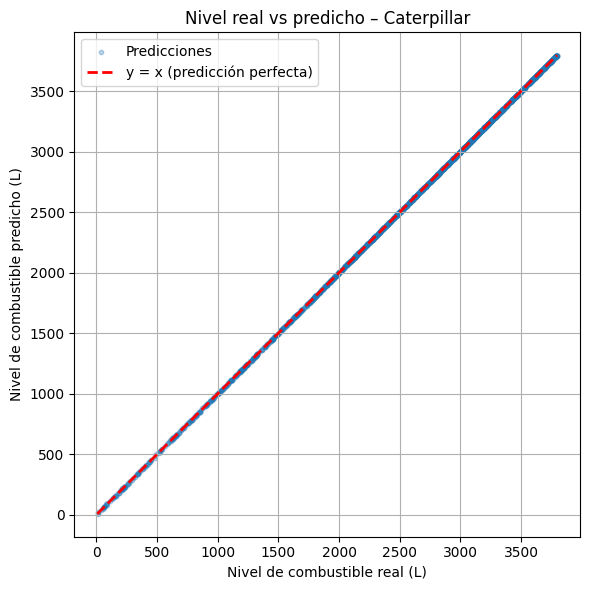

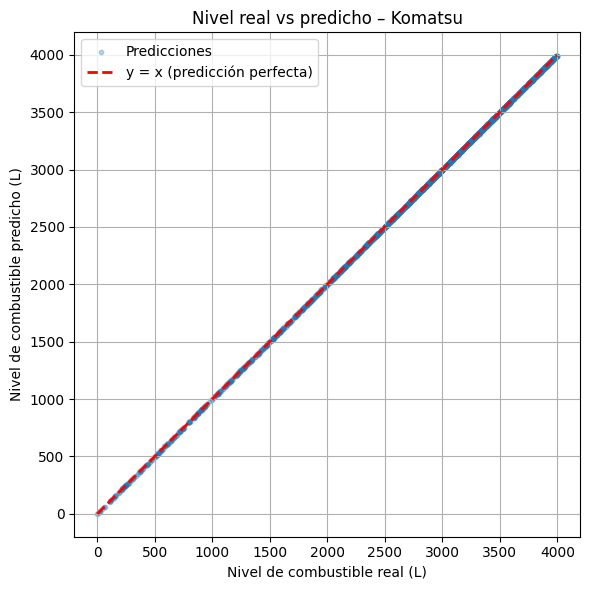

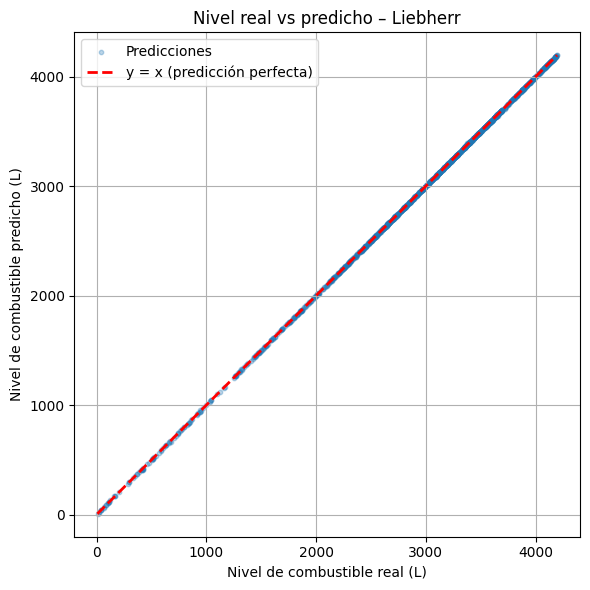

In [ ]:
# ============================
# GRÁFICOS y_real vs y_pred POR MARCA (CAEX)
# Objetivo:
# - Evaluar visualmente la calidad de las predicciones
# - Comparar comportamiento por marca usando el MISMO modelo (regresión lineal)
# ============================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

feature_cols = X_train.columns.tolist()

marcas = {
    "Caterpillar": "marca_Caterpillar",
    "Komatsu": "marca_Komatsu",
    "Liebherr": "marca_Liebherr"
}

for nombre_marca, col_dummy in marcas.items():

    # 1) Filtrar datos de la marca
    df_m = df_feat_model[df_feat_model[col_dummy] == 1].copy()

    X_m = df_m[feature_cols]
    y_m = df_m["nivel_combustible_l"]

    # 2) Train / Test split (mismo criterio que antes)
    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
        X_m, y_m,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    # 3) Entrenar modelo lineal
    model = LinearRegression()
    model.fit(X_train_m, y_train_m)

    # 4) Predicción
    y_pred_m = model.predict(X_test_m)

    # 5) Gráfico y_real vs y_pred
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_m,
        y_pred_m,
        alpha=0.3,
        s=10,
        label="Predicciones"
    )

    # Recta ideal y = x
    min_val = min(y_test_m.min(), y_pred_m.min())
    max_val = max(y_test_m.max(), y_pred_m.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        linewidth=2,
        label="y = x (predicción perfecta)"
    )

    plt.xlabel("Nivel de combustible real (L)")
    plt.ylabel("Nivel de combustible predicho (L)")
    plt.title(f"Nivel real vs predicho – {nombre_marca}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Todas las marcas nos entregan básicamente la misma predicción, por lo que ahora procederemos a estirar los horizontes de predicción,
con esto lograremos bajar la cifra del R2 comprobando asi la efectividad de la predicción del modelo.

In [ ]:
df_work

,equipo_id,tipo_equipo,marca,tipo_motor,timestamp,nivel_combustible_pct,nivel_combustible_l,alarma_baja_combustible_flag
0,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:00:00+00:00,-10.000000,3298.831457,1
1,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:03:00+00:00,99.851064,3295.085119,0
2,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:06:00+00:00,99.665457,3288.960085,0
3,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:09:00+00:00,99.475185,3282.681090,0
4,A02AAA,CAEX,Caterpillar,Diesel,2025-01-01 07:12:00+00:00,99.278939,3276.204980,0
...,...,...,...,...,...,...,...,...
27936,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:49:00+00:00,81.159106,3081.302707,0
27937,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:51:00+00:00,81.159106,3078.193796,0
27938,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:53:00+00:00,80.926621,3075.211612,0
27939,Z95PJD,CAEX,Caterpillar,Diesel,2025-01-01 13:55:00+00:00,80.837679,3071.831807,0


#Predicción a 30 minutos

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================================================
# SCRIPT ROBUSTO (FRECUENCIA IRREGULAR):
# 1) Calcula tasa local de consumo (%/min)
# 2) Construye target FUTURO fuel(t+H) usando merge_asof por equipo
# 3) Entrena modelo para predecir tasa futura media
# 4) Reconstruye fuel_pred(t+H) = fuel(t) + rate_pred * H
#
# Requiere df con: ["equipo_id","timestamp","nivel_combustible_pct"]
# =============================================================================

# -----------------------------
# CONFIG
# -----------------------------
H = 30       # minutos futuro
TOL_FWD = 30 # tolerancia para encontrar punto cercano a t+H (min) (sube si hay gaps)
MAX_DT = 60  # (min) si hay saltos mayores, no calculamos tasa local (evita basura)

# -----------------------------
# 0) Preparación / limpieza
# -----------------------------
df1 = df_work.copy()
df1["equipo_id"] = df1["equipo_id"].astype(str)
df1["timestamp"] = pd.to_datetime(df1["timestamp"], utc=True, errors="coerce")

df1 = df1.dropna(subset=["equipo_id","timestamp","nivel_combustible_pct"]).copy()

# limpiar rango
df1.loc[(df1["nivel_combustible_pct"] < 0) | (df1["nivel_combustible_pct"] > 100), "nivel_combustible_pct"] = np.nan
df1 = df1.dropna(subset=["nivel_combustible_pct"]).copy()

df1 = df1.sort_values(["equipo_id","timestamp"]).reset_index(drop=True)

# -----------------------------
# 1) Tasa local (%/min) por diferencias reales de tiempo
# -----------------------------
df1["dt_min"] = df1.groupby("equipo_id")["timestamp"].diff().dt.total_seconds() / 60.0
df1["d_fuel"] = df1.groupby("equipo_id")["nivel_combustible_pct"].diff()

# descartar dt_min raros o cero
df1.loc[(df1["dt_min"] <= 0) | (df1["dt_min"] > MAX_DT), ["dt_min","d_fuel"]] = np.nan
df1["rate_pct_min"] = df1["d_fuel"] / df1["dt_min"]

# -----------------------------
# 2) Lags de tasa (memoria)
# -----------------------------
for k in [1,2,3,4]:
    df1[f"rate_lag_{k}"] = df1.groupby("equipo_id")["rate_pct_min"].shift(k)

# -----------------------------
# 3) Target futuro fuel(t+H) por equipo con merge_asof
# -----------------------------
parts = []
for eq, g in df1.groupby("equipo_id", sort=False):
    g = g.sort_values("timestamp").reset_index(drop=True)

    left = g[["timestamp"]].copy()
    left["t_fwd"] = left["timestamp"] + pd.Timedelta(minutes=H)
    left = left.sort_values("t_fwd").reset_index(drop=True)

    right = g[["timestamp","nivel_combustible_pct"]].copy()
    right = right.rename(columns={"timestamp":"t_src","nivel_combustible_pct":"fuel_fut"})
    right = right.sort_values("t_src").reset_index(drop=True)

    fut = pd.merge_asof(
        left,
        right,
        left_on="t_fwd",
        right_on="t_src",
        direction="forward",
        tolerance=pd.Timedelta(minutes=H + TOL_FWD)
    )

    # re-alinear a g por timestamp original
    tmp = g[["timestamp"]].merge(fut[["timestamp","fuel_fut"]], on="timestamp", how="left")
    g["fuel_fut"] = tmp["fuel_fut"].values

    parts.append(g)

df2 = pd.concat(parts, ignore_index=True)

# target: tasa media futura en H min
df2["rate_future"] = (df2["fuel_fut"] - df2["nivel_combustible_pct"]) / float(H)

# -----------------------------
# 4) Dataset modelable
# -----------------------------
features = ["rate_pct_min"] + [f"rate_lag_{k}" for k in [1,2,3,4]]
df_model = df2.dropna(subset=features + ["fuel_fut","rate_future"]).copy()

X = df_model[features]
y = df_model["rate_future"]

# -----------------------------
# 5) Split temporal 80/20
# -----------------------------
split_ts = df_model["timestamp"].quantile(0.8)
train_mask = df_model["timestamp"] <= split_ts
test_mask  = df_model["timestamp"] >  split_ts

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print("Train:", X_train.shape, "Test:", X_test.shape)

# -----------------------------
# 6) Modelo
# -----------------------------
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

# -----------------------------
# 7) Predicción de nivel futuro
# -----------------------------
rate_pred = model.predict(X_test)

fuel_now  = df_model.loc[test_mask, "nivel_combustible_pct"].values
fuel_true = df_model.loc[test_mask, "fuel_fut"].values

fuel_pred = fuel_now + rate_pred * H

mae = mean_absolute_error(fuel_true, fuel_pred)
r2  = r2_score(fuel_true, fuel_pred)

print(f"\nHorizonte +{H} min")
print("MAE fuel:", round(mae, 4))
print("R2 fuel :", round(r2, 4))

# ver algunas filas
check = df_model.loc[test_mask, ["equipo_id","timestamp","nivel_combustible_pct","fuel_fut"]].copy()
check["fuel_pred"] = fuel_pred
check["err"] = check["fuel_fut"] - check["fuel_pred"]
print("\nMuestra:")
print(check.head(10))

Train: (20805, 5) Test: (5196, 5)

Horizonte +30 min
MAE fuel: 1.0034
R2 fuel : 0.9739

Muestra:
    equipo_id                 timestamp  nivel_combustible_pct   fuel_fut  \
551    A10AAA 2025-01-02 06:06:00+00:00              32.984899  31.552246   
552    A10AAA 2025-01-02 06:09:00+00:00              32.984899  31.465085   
553    A10AAA 2025-01-02 06:12:00+00:00              32.737588  31.303400   
554    A10AAA 2025-01-02 06:15:00+00:00              32.596573  31.141519   
555    A10AAA 2025-01-02 06:18:00+00:00              32.447938  30.976426   
556    A10AAA 2025-01-02 06:21:00+00:00              32.284179  30.801703   
557    A10AAA 2025-01-02 06:24:00+00:00              32.124206  30.622689   
558    A10AAA 2025-01-02 06:27:00+00:00              31.943681  30.465362   
559    A10AAA 2025-01-02 06:30:00+00:00              31.809351  30.306244   
560    A10AAA 2025-01-02 06:33:00+00:00              31.809351  30.136693   

     fuel_pred       err  
551  31.386877  0.165368  
5

#Predicción a 60 minutos

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================================================
# SCRIPT ROBUSTO (FRECUENCIA IRREGULAR):
# 1) Calcula tasa local de consumo (%/min)
# 2) Construye target FUTURO fuel(t+H) usando merge_asof por equipo
# 3) Entrena modelo para predecir tasa futura media
# 4) Reconstruye fuel_pred(t+H) = fuel(t) + rate_pred * H
#
# Requiere df con: ["equipo_id","timestamp","nivel_combustible_pct"]
# =============================================================================

# -----------------------------
# CONFIG
# -----------------------------
H = 60       # minutos futuro
TOL_FWD = 60 # tolerancia para encontrar punto cercano a t+H (min) (sube si hay gaps)
MAX_DT = 60  # (min) si hay saltos mayores, no calculamos tasa local (evita basura)

# -----------------------------
# 0) Preparación / limpieza
# -----------------------------
df1 = df_work.copy()
df1["equipo_id"] = df1["equipo_id"].astype(str)
df1["timestamp"] = pd.to_datetime(df1["timestamp"], utc=True, errors="coerce")

df1 = df1.dropna(subset=["equipo_id","timestamp","nivel_combustible_pct"]).copy()

# limpiar rango
df1.loc[(df1["nivel_combustible_pct"] < 0) | (df1["nivel_combustible_pct"] > 100), "nivel_combustible_pct"] = np.nan
df1 = df1.dropna(subset=["nivel_combustible_pct"]).copy()

df1 = df1.sort_values(["equipo_id","timestamp"]).reset_index(drop=True)

# -----------------------------
# 1) Tasa local (%/min) por diferencias reales de tiempo
# -----------------------------
df1["dt_min"] = df1.groupby("equipo_id")["timestamp"].diff().dt.total_seconds() / 60.0
df1["d_fuel"] = df1.groupby("equipo_id")["nivel_combustible_pct"].diff()

# descartar dt_min raros o cero
df1.loc[(df1["dt_min"] <= 0) | (df1["dt_min"] > MAX_DT), ["dt_min","d_fuel"]] = np.nan
df1["rate_pct_min"] = df1["d_fuel"] / df1["dt_min"]

# -----------------------------
# 2) Lags de tasa (memoria)
# -----------------------------
for k in [1,2,3,4]:
    df1[f"rate_lag_{k}"] = df1.groupby("equipo_id")["rate_pct_min"].shift(k)

# -----------------------------
# 3) Target futuro fuel(t+H) por equipo con merge_asof
# -----------------------------
parts = []
for eq, g in df1.groupby("equipo_id", sort=False):
    g = g.sort_values("timestamp").reset_index(drop=True)

    left = g[["timestamp"]].copy()
    left["t_fwd"] = left["timestamp"] + pd.Timedelta(minutes=H)
    left = left.sort_values("t_fwd").reset_index(drop=True)

    right = g[["timestamp","nivel_combustible_pct"]].copy()
    right = right.rename(columns={"timestamp":"t_src","nivel_combustible_pct":"fuel_fut"})
    right = right.sort_values("t_src").reset_index(drop=True)

    fut = pd.merge_asof(
        left,
        right,
        left_on="t_fwd",
        right_on="t_src",
        direction="forward",
        tolerance=pd.Timedelta(minutes=H + TOL_FWD)
    )

    # re-alinear a g por timestamp original
    tmp = g[["timestamp"]].merge(fut[["timestamp","fuel_fut"]], on="timestamp", how="left")
    g["fuel_fut"] = tmp["fuel_fut"].values

    parts.append(g)

df2 = pd.concat(parts, ignore_index=True)

# target: tasa media futura en H min
df2["rate_future"] = (df2["fuel_fut"] - df2["nivel_combustible_pct"]) / float(H)

# -----------------------------
# 4) Dataset modelable
# -----------------------------
features = ["rate_pct_min"] + [f"rate_lag_{k}" for k in [1,2,3,4]]
df_model = df2.dropna(subset=features + ["fuel_fut","rate_future"]).copy()

X = df_model[features]
y = df_model["rate_future"]

# -----------------------------
# 5) Split temporal 80/20
# -----------------------------
split_ts = df_model["timestamp"].quantile(0.8)
train_mask = df_model["timestamp"] <= split_ts
test_mask  = df_model["timestamp"] >  split_ts

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print("Train:", X_train.shape, "Test:", X_test.shape)

# -----------------------------
# 6) Modelo
# -----------------------------
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

# -----------------------------
# 7) Predicción de nivel futuro
# -----------------------------
rate_pred = model.predict(X_test)

fuel_now  = df_model.loc[test_mask, "nivel_combustible_pct"].values
fuel_true = df_model.loc[test_mask, "fuel_fut"].values

fuel_pred = fuel_now + rate_pred * H

mae = mean_absolute_error(fuel_true, fuel_pred)
r2  = r2_score(fuel_true, fuel_pred)

print(f"\nHorizonte +{H} min")
print("MAE fuel:", round(mae, 4))
print("R2 fuel :", round(r2, 4))

# ver algunas filas
check = df_model.loc[test_mask, ["equipo_id","timestamp","nivel_combustible_pct","fuel_fut"]].copy()
check["fuel_pred"] = fuel_pred
check["err"] = check["fuel_fut"] - check["fuel_pred"]
print("\nMuestra:")
print(check.head(10))

Train: (19987, 5) Test: (4993, 5)

Horizonte +60 min
MAE fuel: 1.7628
R2 fuel : 0.9407

Muestra:
    equipo_id                 timestamp  nivel_combustible_pct   fuel_fut  \
557    A10AAA 2025-01-02 06:24:00+00:00              32.124206  29.261541   
558    A10AAA 2025-01-02 06:27:00+00:00              31.943681  29.085275   
559    A10AAA 2025-01-02 06:30:00+00:00              31.809351  28.918529   
560    A10AAA 2025-01-02 06:33:00+00:00              31.809351  28.757320   
561    A10AAA 2025-01-02 06:36:00+00:00              31.552246  28.757320   
562    A10AAA 2025-01-02 06:39:00+00:00              31.465085  28.482317   
563    A10AAA 2025-01-02 06:42:00+00:00              31.303400  28.353270   
564    A10AAA 2025-01-02 06:45:00+00:00              31.141519  28.222844   
565    A10AAA 2025-01-02 06:48:00+00:00              30.976426  28.130168   
566    A10AAA 2025-01-02 06:51:00+00:00              30.801703  27.951899   

     fuel_pred       err  
557  29.083685  0.177856  
5

#Predicción a 90 Minutos

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================================================
# SCRIPT ROBUSTO (FRECUENCIA IRREGULAR):
# 1) Calcula tasa local de consumo (%/min)
# 2) Construye target FUTURO fuel(t+H) usando merge_asof por equipo
# 3) Entrena modelo para predecir tasa futura media
# 4) Reconstruye fuel_pred(t+H) = fuel(t) + rate_pred * H
#
# Requiere df con: ["equipo_id","timestamp","nivel_combustible_pct"]
# =============================================================================

# -----------------------------
# CONFIG
# -----------------------------
H = 90       # minutos futuro
TOL_FWD = 90 # tolerancia para encontrar punto cercano a t+H (min) (sube si hay gaps)
MAX_DT = 90  # (min) si hay saltos mayores, no calculamos tasa local (evita basura)

# -----------------------------
# 0) Preparación / limpieza
# -----------------------------
df1 = df_work.copy()
df1["equipo_id"] = df1["equipo_id"].astype(str)
df1["timestamp"] = pd.to_datetime(df1["timestamp"], utc=True, errors="coerce")

df1 = df1.dropna(subset=["equipo_id","timestamp","nivel_combustible_pct"]).copy()

# limpiar rango
df1.loc[(df1["nivel_combustible_pct"] < 0) | (df1["nivel_combustible_pct"] > 100), "nivel_combustible_pct"] = np.nan
df1 = df1.dropna(subset=["nivel_combustible_pct"]).copy()

df1 = df1.sort_values(["equipo_id","timestamp"]).reset_index(drop=True)

# -----------------------------
# 1) Tasa local (%/min) por diferencias reales de tiempo
# -----------------------------
df1["dt_min"] = df1.groupby("equipo_id")["timestamp"].diff().dt.total_seconds() / 60.0
df1["d_fuel"] = df1.groupby("equipo_id")["nivel_combustible_pct"].diff()

# descartar dt_min raros o cero
df1.loc[(df1["dt_min"] <= 0) | (df1["dt_min"] > MAX_DT), ["dt_min","d_fuel"]] = np.nan
df1["rate_pct_min"] = df1["d_fuel"] / df1["dt_min"]

# -----------------------------
# 2) Lags de tasa (memoria)
# -----------------------------
for k in [1,2,3,4]:
    df1[f"rate_lag_{k}"] = df1.groupby("equipo_id")["rate_pct_min"].shift(k)

# -----------------------------
# 3) Target futuro fuel(t+H) por equipo con merge_asof
# -----------------------------
parts = []
for eq, g in df1.groupby("equipo_id", sort=False):
    g = g.sort_values("timestamp").reset_index(drop=True)

    left = g[["timestamp"]].copy()
    left["t_fwd"] = left["timestamp"] + pd.Timedelta(minutes=H)
    left = left.sort_values("t_fwd").reset_index(drop=True)

    right = g[["timestamp","nivel_combustible_pct"]].copy()
    right = right.rename(columns={"timestamp":"t_src","nivel_combustible_pct":"fuel_fut"})
    right = right.sort_values("t_src").reset_index(drop=True)

    fut = pd.merge_asof(
        left,
        right,
        left_on="t_fwd",
        right_on="t_src",
        direction="forward",
        tolerance=pd.Timedelta(minutes=H + TOL_FWD)
    )

    # re-alinear a g por timestamp original
    tmp = g[["timestamp"]].merge(fut[["timestamp","fuel_fut"]], on="timestamp", how="left")
    g["fuel_fut"] = tmp["fuel_fut"].values

    parts.append(g)

df2 = pd.concat(parts, ignore_index=True)

# target: tasa media futura en H min
df2["rate_future"] = (df2["fuel_fut"] - df2["nivel_combustible_pct"]) / float(H)

# -----------------------------
# 4) Dataset modelable
# -----------------------------
features = ["rate_pct_min"] + [f"rate_lag_{k}" for k in [1,2,3,4]]
df_model = df2.dropna(subset=features + ["fuel_fut","rate_future"]).copy()

X = df_model[features]
y = df_model["rate_future"]

# -----------------------------
# 5) Split temporal 80/20
# -----------------------------
split_ts = df_model["timestamp"].quantile(0.8)
train_mask = df_model["timestamp"] <= split_ts
test_mask  = df_model["timestamp"] >  split_ts

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print("Train:", X_train.shape, "Test:", X_test.shape)

# -----------------------------
# 6) Modelo
# -----------------------------
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

# -----------------------------
# 7) Predicción de nivel futuro
# -----------------------------
rate_pred = model.predict(X_test)

fuel_now  = df_model.loc[test_mask, "nivel_combustible_pct"].values
fuel_true = df_model.loc[test_mask, "fuel_fut"].values

fuel_pred = fuel_now + rate_pred * H

mae = mean_absolute_error(fuel_true, fuel_pred)
r2  = r2_score(fuel_true, fuel_pred)

print(f"\nHorizonte +{H} min")
print("MAE fuel:", round(mae, 4))
print("R2 fuel :", round(r2, 4))

# ver algunas filas
check = df_model.loc[test_mask, ["equipo_id","timestamp","nivel_combustible_pct","fuel_fut"]].copy()
check["fuel_pred"] = fuel_pred
check["err"] = check["fuel_fut"] - check["fuel_pred"]
print("\nMuestra:")
print(check.head(10))

Train: (19190, 5) Test: (4795, 5)

Horizonte +90 min
MAE fuel: 2.8229
R2 fuel : 0.8693

Muestra:
    equipo_id                 timestamp  nivel_combustible_pct   fuel_fut  \
562    A10AAA 2025-01-02 06:39:00+00:00              31.465085  26.986767   
563    A10AAA 2025-01-02 06:42:00+00:00              31.303400  26.986767   
564    A10AAA 2025-01-02 06:45:00+00:00              31.141519  26.986767   
565    A10AAA 2025-01-02 06:48:00+00:00              30.976426  26.596601   
566    A10AAA 2025-01-02 06:51:00+00:00              30.801703  26.486869   
567    A10AAA 2025-01-02 06:54:00+00:00              30.622689  26.486869   
568    A10AAA 2025-01-02 06:57:00+00:00              30.465362  26.162300   
569    A10AAA 2025-01-02 07:00:00+00:00              30.306244  26.162300   
570    A10AAA 2025-01-02 07:03:00+00:00              30.136693  25.830769   
571    A10AAA 2025-01-02 07:06:00+00:00              30.004926  25.633880   

     fuel_pred       err  
562  27.339279 -0.352512  
5

#Unión de los 30, 60 y 90 Minutos + Logística de recarga de Combustible

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================================================
# TODO-EN-UNO:
# A) Entrena modelos de predicción de combustible para H = 30, 60, 90 min (frecuencia irregular)
#    - Modela la TASA futura media (rate_future) y reconstruye fuel(t+H)
# B) Con las predicciones (30/60/90) arma "foto ahora" por camión
# C) Calcula criterio logístico: tiempo a reserva + deadline para decidir quién debe ir a recargar
#    (sin cola/slots todavía; te deja la lista priorizada y semáforo)
#
# Requiere df con: ["equipo_id","timestamp","nivel_combustible_pct"]
# =============================================================================

# -----------------------------
# CONFIG GENERAL
# -----------------------------
H_LIST = [30, 60, 90]          # horizontes
MAX_DT = 60                   # (min) si hay saltos mayores, no calculamos tasa local
TOL_FWD_RULE = lambda H: H    # tolerancia para buscar fuel_fut cerca de t+H
LAGS_K = [1, 2, 3, 4]          # memoria de tasa

# --- LOGÍSTICA (ajusta a tu operación) ---
MIN_RESERVE_PCT = 12          # reserva mínima segura (%)
BUFFER_MIN = 8                # margen (min) antes de quedar en reserva
TRAVEL_TO_FUEL_MIN_DEFAULT = 12   # si no tienes travel time por camión, usa un default

# -----------------------------
# 0) Preparación / limpieza
# -----------------------------
df1 = df_work.copy()
df1["equipo_id"] = df1["equipo_id"].astype(str)
df1["timestamp"] = pd.to_datetime(df1["timestamp"], utc=True, errors="coerce")

df1 = df1.dropna(subset=["equipo_id", "timestamp", "nivel_combustible_pct"]).copy()

# limpiar rango de %
df1.loc[(df1["nivel_combustible_pct"] < 0) | (df1["nivel_combustible_pct"] > 100),
        "nivel_combustible_pct"] = np.nan
df1 = df1.dropna(subset=["nivel_combustible_pct"]).copy()

df1 = df1.sort_values(["equipo_id", "timestamp"]).reset_index(drop=True)

# -----------------------------
# 1) Tasa local (%/min) con dt real (robusto a frecuencia irregular)
# -----------------------------
df1["dt_min"] = df1.groupby("equipo_id")["timestamp"].diff().dt.total_seconds() / 60.0
df1["d_fuel"] = df1.groupby("equipo_id")["nivel_combustible_pct"].diff()

df1.loc[(df1["dt_min"] <= 0) | (df1["dt_min"] > MAX_DT), ["dt_min", "d_fuel"]] = np.nan
df1["rate_pct_min"] = df1["d_fuel"] / df1["dt_min"]

# lags de tasa
for k in LAGS_K:
    df1[f"rate_lag_{k}"] = df1.groupby("equipo_id")["rate_pct_min"].shift(k)

# features base (no dependen del horizonte)
FEATURES = ["rate_pct_min"] + [f"rate_lag_{k}" for k in LAGS_K]

# -----------------------------
# Función: construir fuel_fut (t+H) con merge_asof por equipo (evita errores de orden)
# -----------------------------
def build_future_target_by_equipo(df_in: pd.DataFrame, H: int, tol_fwd: int) -> pd.DataFrame:
    parts = []
    for eq, g in df_in.groupby("equipo_id", sort=False):
        g = g.sort_values("timestamp").reset_index(drop=True)

        left = g[["timestamp"]].copy()
        left["t_fwd"] = left["timestamp"] + pd.Timedelta(minutes=H)
        left = left.sort_values("t_fwd").reset_index(drop=True)

        right = g[["timestamp", "nivel_combustible_pct"]].copy()
        right = right.rename(columns={"timestamp": "t_src", "nivel_combustible_pct": "fuel_fut"})
        right = right.sort_values("t_src").reset_index(drop=True)

        fut = pd.merge_asof(
            left,
            right,
            left_on="t_fwd",
            right_on="t_src",
            direction="forward",
            tolerance=pd.Timedelta(minutes=H + tol_fwd),
        )

        tmp = g[["timestamp"]].merge(fut[["timestamp", "fuel_fut"]], on="timestamp", how="left")
        g["fuel_fut"] = tmp["fuel_fut"].values
        parts.append(g)

    out = pd.concat(parts, ignore_index=True)
    out["rate_future"] = (out["fuel_fut"] - out["nivel_combustible_pct"]) / float(H)
    return out

# -----------------------------
# 2) Entrenar 3 modelos (30/60/90) y generar predicciones
# -----------------------------
models = {}
evals = []
pred_frames = []

for H in H_LIST:
    TOL_FWD = int(TOL_FWD_RULE(H))

    # construir target para este H
    dfH = build_future_target_by_equipo(df1, H=H, tol_fwd=TOL_FWD)

    # dataset modelable
    df_model = dfH.dropna(subset=FEATURES + ["fuel_fut", "rate_future"]).copy()

    # split temporal 80/20
    split_ts = df_model["timestamp"].quantile(0.8)
    train_mask = df_model["timestamp"] <= split_ts
    test_mask  = df_model["timestamp"] >  split_ts

    X_train = df_model.loc[train_mask, FEATURES]
    y_train = df_model.loc[train_mask, "rate_future"]

    X_test  = df_model.loc[test_mask, FEATURES]
    fuel_now_test  = df_model.loc[test_mask, "nivel_combustible_pct"].values
    fuel_true_test = df_model.loc[test_mask, "fuel_fut"].values

    # modelo (puedes tunear)
    model = GradientBoostingRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X_train, y_train)
    models[H] = model

    # predicción tasa -> predicción nivel
    rate_pred = model.predict(X_test)
    fuel_pred = fuel_now_test + rate_pred * H

    mae = mean_absolute_error(fuel_true_test, fuel_pred)
    r2  = r2_score(fuel_true_test, fuel_pred)

    evals.append({"H_min": H, "MAE_fuel": mae, "R2_fuel": r2, "n_test": len(fuel_pred)})

    # guardar predicciones test (útil para revisar)
    pred_tmp = df_model.loc[test_mask, ["equipo_id", "timestamp", "nivel_combustible_pct", "fuel_fut"]].copy()
    pred_tmp = pred_tmp.rename(columns={"nivel_combustible_pct": "fuel_now_pct", "fuel_fut": f"fuel_true_{H}"})
    pred_tmp[f"fuel_pred_{H}"] = fuel_pred
    pred_frames.append(pred_tmp)

eval_df = pd.DataFrame(evals).sort_values("H_min")
print("\n=== EVALUACIÓN MODELOS (por horizonte) ===")
print(eval_df.to_string(index=False))

# -----------------------------
# 3) FOTO "AHORA" por camión + predicciones 30/60/90
#    (usa el ÚLTIMO registro real por equipo y predice con cada modelo)
# -----------------------------
df_now = (df1.sort_values(["equipo_id", "timestamp"])
            .groupby("equipo_id", as_index=False)
            .tail(1)
            .reset_index(drop=True))

X_now = df_now[FEATURES].copy()

# puede haber NaN en features por falta de historia: los removemos (o imputas)
df_now_ok = df_now.dropna(subset=FEATURES).copy()
X_now_ok = df_now_ok[FEATURES]

for H in H_LIST:
    rate_now_pred = models[H].predict(X_now_ok)
    df_now_ok[f"fuel_pred_{H}"] = df_now_ok["nivel_combustible_pct"].values + rate_now_pred * H

# renombres
df_now_ok = df_now_ok.rename(columns={"nivel_combustible_pct": "fuel_now_pct"})

# -----------------------------
# 4) CRITERIO LOGÍSTICO: ¿cuándo debe ir a recargar?
#    Usa pred_30 y pred_90 para estimar "pendiente" (consumo) y tiempo a reserva.
# -----------------------------
# travel time (si no lo tienes, ponemos un default fijo)
if "t_travel_to_fuel_min" not in df_now_ok.columns:
    df_now_ok["t_travel_to_fuel_min"] = TRAVEL_TO_FUEL_MIN_DEFAULT

# tasa aproximada usando predicciones 30 y 90 (60 min entre ellas)
# rate < 0 => está bajando
df_now_ok["rate_from_pred_pct_min"] = (df_now_ok["fuel_pred_90"] - df_now_ok["fuel_pred_30"]) / 60.0

# tiempo hasta llegar a reserva (min)
df_now_ok["t_to_reserve_min"] = np.where(
    df_now_ok["rate_from_pred_pct_min"] < 0,
    (df_now_ok["fuel_now_pct"] - MIN_RESERVE_PCT) / (-df_now_ok["rate_from_pred_pct_min"]),
    np.inf
)

# deadline: último minuto (desde ahora) para SALIR hacia el surtidor sin cruzar reserva
df_now_ok["deadline_min"] = df_now_ok["t_to_reserve_min"] - df_now_ok["t_travel_to_fuel_min"] - BUFFER_MIN

# semáforo simple
df_now_ok["semaforo"] = np.select(
    [df_now_ok["deadline_min"] <= 0, df_now_ok["deadline_min"] <= 30],
    ["ROJO", "AMARILLO"],
    default="VERDE"
)

# Ranking para despacho: primero ROJO, luego menor deadline
df_now_ok["rank"] = df_now_ok["deadline_min"].rank(method="first")

cols_out = [
    "equipo_id", "timestamp",
    "fuel_now_pct",
    "fuel_pred_30", "fuel_pred_60", "fuel_pred_90",
    "rate_from_pred_pct_min",
    "t_to_reserve_min", "t_travel_to_fuel_min",
    "deadline_min", "semaforo"
]

print("\n=== LISTA LOGÍSTICA (¿quién debe ir a recargar?) ===")
print(df_now_ok[cols_out].sort_values(["semaforo", "deadline_min"], ascending=[True, True]).head(30).to_string(index=False))

# -----------------------------
# 5) (OPCIONAL) si quieres guardar resultados
# -----------------------------
# df_now_ok.to_csv("fuel_now_with_preds_and_dispatch.csv", index=False)
# pd.concat(pred_frames, ignore_index=True).to_csv("fuel_preds_test_30_60_90.csv", index=False)


=== EVALUACIÓN MODELOS (por horizonte) ===
 H_min  MAE_fuel  R2_fuel  n_test
    30  1.003370 0.973878    5196
    60  1.762751 0.940684    4993
    90  2.822868 0.869335    4795

=== LISTA LOGÍSTICA (¿quién debe ir a recargar?) ===
equipo_id                 timestamp  fuel_now_pct  fuel_pred_30  fuel_pred_60  fuel_pred_90  rate_from_pred_pct_min  t_to_reserve_min  t_travel_to_fuel_min  deadline_min semaforo
   A64AAA 2025-01-02 15:56:00+00:00     13.037845     11.675657     10.316009      8.871705               -0.046733         22.208203                    12      2.208203 AMARILLO
   D59HZR 2025-01-02 09:55:00+00:00     13.910013     12.506820     10.804318      9.375077               -0.052196         36.593280                    12     16.593280 AMARILLO
   I76KGC 2025-01-02 20:56:00+00:00      2.190069      1.815028     -0.442685      0.127002               -0.028134       -348.688809                    12   -368.688809     ROJO
   F63DHL 2025-01-02 17:48:00+00:00      1.209166 

#Visualizaciones


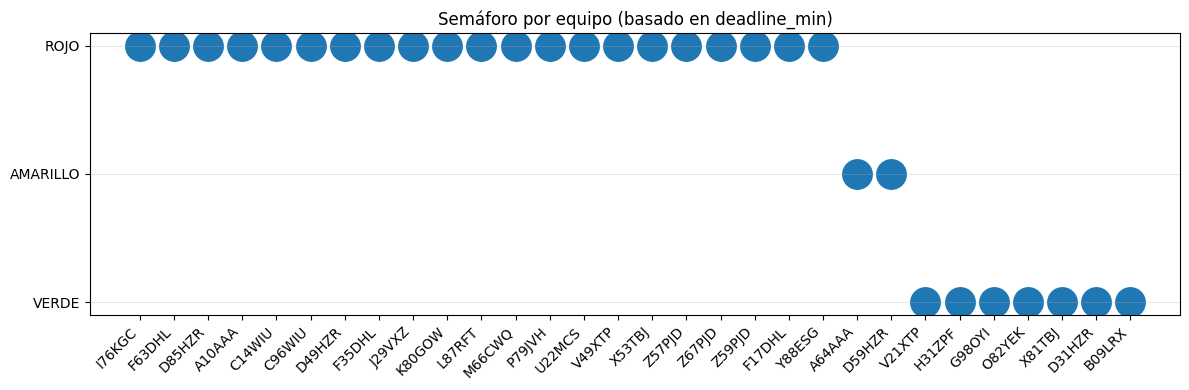

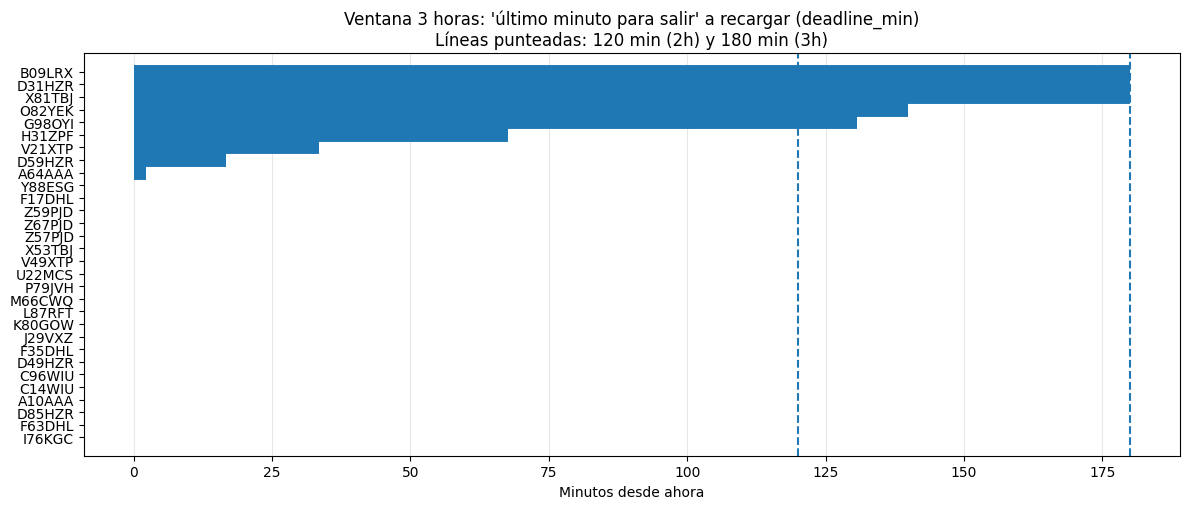


=== Equipos que deberían salir a recargar ANTES de 120 min (deadline<=120) ===


KeyError: 'prio'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# GRÁFICOS (solo visualización) usando df_now_ok que ya construiste
# 1) Semáforo por equipo (círculos VERDE/AMARILLO/ROJO)
# 2) Ventana 3 horas: quiénes "caen" antes de 120 min (2h) y antes de 180 min (3h)
# =============================================================================

WINDOW_MIN = 180   # 3 horas
CUT_120 = 120      # 2 horas
TOP_N = 30         # máximo equipos en los gráficos para que no se vea lleno

# Ordenar por urgencia como ya venías haciendo
order_map = {"ROJO": 0, "AMARILLO": 1, "VERDE": 2}
dfv = df_now_ok.copy()
dfv["prio"] = dfv["semaforo"].map(order_map).fillna(9).astype(int)
dfv = dfv.sort_values(["prio", "deadline_min"], ascending=[True, True]).reset_index(drop=True)

# Tomamos los TOP_N más urgentes para que el gráfico sea legible
dpg = dfv.head(TOP_N).copy()

# -----------------------------
# 1) Semáforo (círculos) vs equipo
# -----------------------------
# Mapear semáforo a eje y (VERDE=0, AMARILLO=1, ROJO=2) para forma "semaforo"
sem2y = {"VERDE": 0, "AMARILLO": 1, "ROJO": 2}
dpg["sem_y"] = dpg["semaforo"].map(sem2y).fillna(0)

x = np.arange(len(dpg))

plt.figure(figsize=(12, 4))
plt.scatter(x, dpg["sem_y"], s=450, marker="o")
plt.yticks([0, 1, 2], ["VERDE", "AMARILLO", "ROJO"])
plt.xticks(x, dpg["equipo_id"], rotation=45, ha="right")
plt.title("Semáforo por equipo (basado en deadline_min)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Ventana 3 horas: timeline por deadline
# (barra desde 0 hasta deadline_min)
# -----------------------------
dpg2 = dfv[dfv["deadline_min"].notna()].copy()
dpg2 = dpg2.sort_values(["prio", "deadline_min"], ascending=[True, True]).head(TOP_N).reset_index(drop=True)

y = np.arange(len(dpg2))
x_end = dpg2["deadline_min"].clip(lower=0, upper=WINDOW_MIN).values

plt.figure(figsize=(12, 5.2))
plt.hlines(y=y, xmin=0, xmax=x_end, linewidth=10)

# líneas de referencia 120 y 180 min
plt.axvline(CUT_120, linestyle="--")
plt.axvline(WINDOW_MIN, linestyle="--")

plt.yticks(y, dpg2["equipo_id"])
plt.xlabel("Minutos desde ahora")
plt.title("Ventana 3 horas: 'último minuto para salir' a recargar (deadline_min)\n"
          "Líneas punteadas: 120 min (2h) y 180 min (3h)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Listas directas para tu explicación (sin agregar lógica)
# -----------------------------
dfv["must_by_120"] = dfv["deadline_min"] <= CUT_120
dfv["must_by_180"] = dfv["deadline_min"] <= WINDOW_MIN

print("\n=== Equipos que deberían salir a recargar ANTES de 120 min (deadline<=120) ===")
print(dfv.loc[dfv["must_by_120"], ["equipo_id","fuel_now_pct","fuel_pred_30","fuel_pred_60","fuel_pred_90",
                                  "deadline_min","semaforo"]]
      .sort_values(["prio","deadline_min"]).to_string(index=False))

print("\n=== Equipos que caen dentro de la ventana 3 horas (deadline<=180) ===")
print(dfv.loc[dfv["must_by_180"], ["equipo_id","fuel_now_pct","fuel_pred_30","fuel_pred_60","fuel_pred_90",
                                  "deadline_min","semaforo"]]
      .sort_values(["prio","deadline_min"]).to_string(index=False))

Ahora procederemos a generar un semaforo real que nos permita conocer a simple vista que camiones están prontos a entrar a la deadline, y poder con esta informacion generar la logistica necesaria que permita a la minera evitar los fallos inesperados por falta de combustible en los camiones CAEX

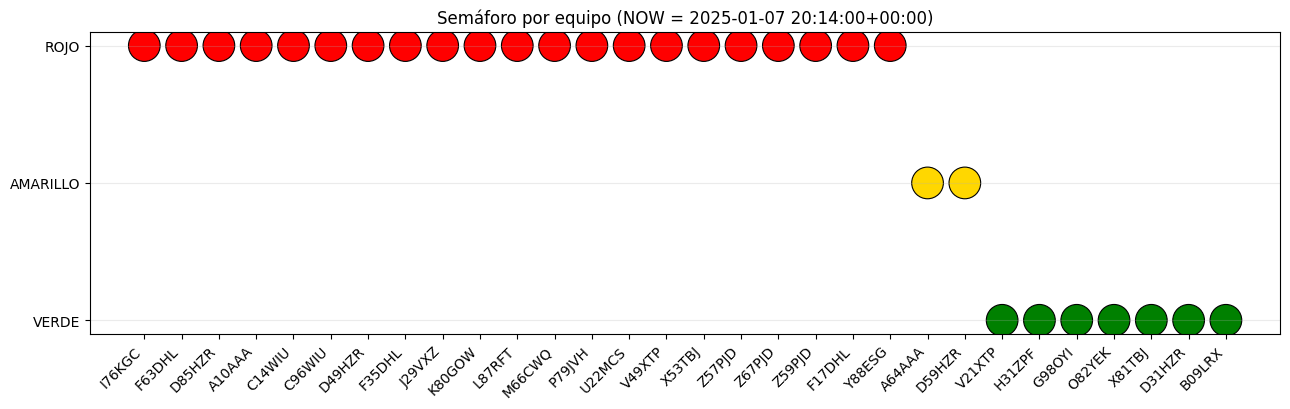

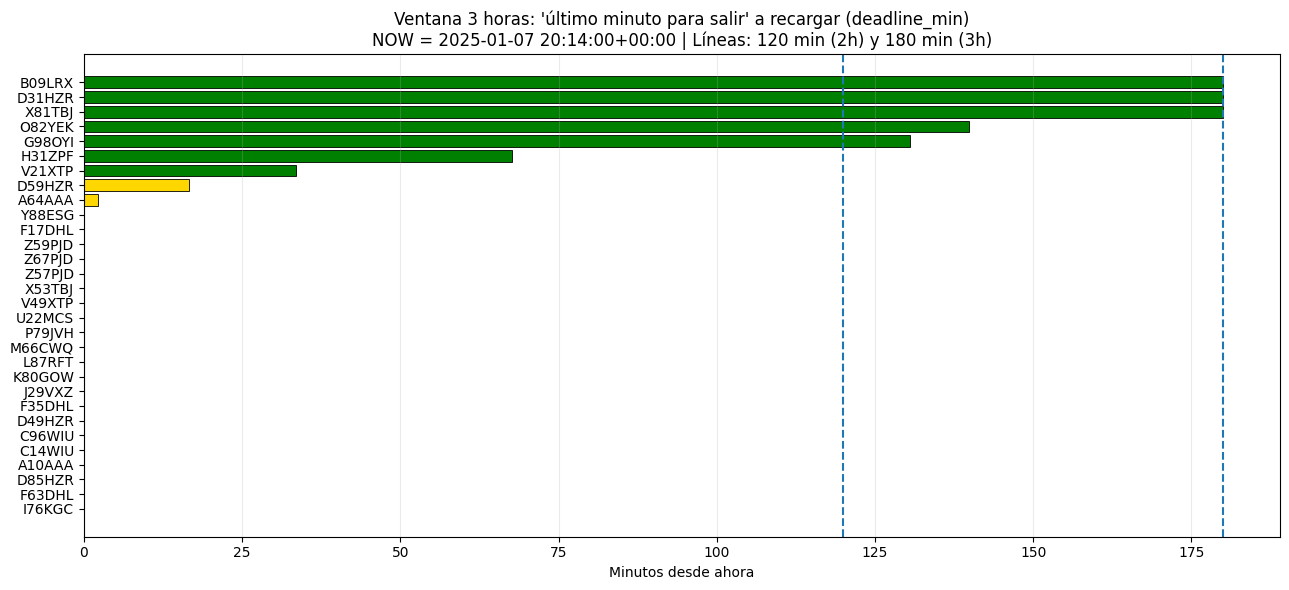


=== Equipos que deberían salir a recargar ANTES de 120 min (deadline<=120) ===
equipo_id  fuel_now_pct  fuel_pred_30  fuel_pred_60  fuel_pred_90  deadline_min semaforo  prio
   I76KGC      2.190069      1.815028     -0.442685      0.127002   -368.688809     ROJO     0
   F63DHL      1.209166     -0.394566     -1.726519     -3.116762   -257.841097     ROJO     0
   D85HZR      2.443768      1.056176     -0.209243     -1.456744   -248.170336     ROJO     0
   A10AAA      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO     0
   C14WIU      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO     0
   C96WIU      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO     0
   D49HZR      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO     0
   F35DHL      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO     0
   J29VXZ      0.000000     -1.536145     -2.885849     -4.829156

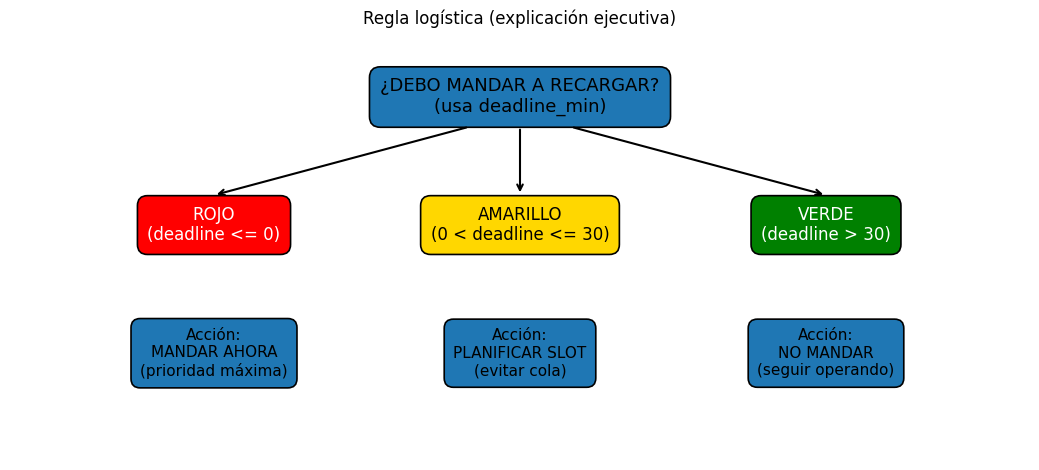

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIG VISUAL
# =========================
WINDOW_MIN = 180
CUT_120 = 120
TOP_N = 30

# 1) Copia y orden (sin depender de 'prio' existente)
dfv = df_now_ok.copy()

# timestamp "ahora" para el título (último timestamp real)
now_ts = pd.to_datetime(dfv["timestamp"].max())

# Crear prio SIEMPRE (arregla el KeyError)
order_map = {"ROJO": 0, "AMARILLO": 1, "VERDE": 2}
dfv["prio"] = dfv["semaforo"].map(order_map).fillna(9).astype(int)

dfv = dfv.sort_values(["prio", "deadline_min"], ascending=[True, True]).reset_index(drop=True)

# Limitar para visualización (los más urgentes)
dpg = dfv.head(TOP_N).copy()

# =========================
# 2) SEMÁFORO con COLORES reales
# =========================
# Colores reales por semáforo
color_map = {"VERDE": "green", "AMARILLO": "gold", "ROJO": "red"}
dpg["color"] = dpg["semaforo"].map(color_map).fillna("gray")

# Eje Y como semáforo (0 verde, 1 amarillo, 2 rojo)
sem2y = {"VERDE": 0, "AMARILLO": 1, "ROJO": 2}
dpg["sem_y"] = dpg["semaforo"].map(sem2y).fillna(-1)

x = np.arange(len(dpg))

plt.figure(figsize=(13, 4.2))
plt.scatter(x, dpg["sem_y"], s=520, c=dpg["color"], edgecolors="black", linewidths=0.8)

plt.yticks([0, 1, 2], ["VERDE", "AMARILLO", "ROJO"])
plt.xticks(x, dpg["equipo_id"], rotation=45, ha="right")

plt.title(f"Semáforo por equipo (NOW = {now_ts})")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# 3) VENTANA 3 HORAS (mucho más informativa)
#    - barras horizontales hasta deadline
#    - color por semáforo
# =========================
dpg2 = dfv[dfv["deadline_min"].notna()].head(TOP_N).copy()
y = np.arange(len(dpg2))

# recortar a la ventana [0, 180]
x_end = dpg2["deadline_min"].clip(lower=0, upper=WINDOW_MIN).values
colors = dpg2["semaforo"].map(color_map).fillna("gray").values

plt.figure(figsize=(13, 6))
plt.barh(y, x_end, color=colors, edgecolor="black", linewidth=0.6)

plt.axvline(CUT_120, linestyle="--")
plt.axvline(WINDOW_MIN, linestyle="--")

plt.yticks(y, dpg2["equipo_id"])
plt.xlabel("Minutos desde ahora")
plt.title(f"Ventana 3 horas: 'último minuto para salir' a recargar (deadline_min)\n"
          f"NOW = {now_ts} | Líneas: 120 min (2h) y 180 min (3h)")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# 4) LISTAS SIN ERROR (ya existe 'prio')
# =========================
dfv["must_by_120"] = dfv["deadline_min"] <= CUT_120
dfv["must_by_180"] = dfv["deadline_min"] <= WINDOW_MIN

print("\n=== Equipos que deberían salir a recargar ANTES de 120 min (deadline<=120) ===")
print(dfv.loc[dfv["must_by_120"],
              ["equipo_id","fuel_now_pct","fuel_pred_30","fuel_pred_60","fuel_pred_90","deadline_min","semaforo","prio"]]
      .sort_values(["prio","deadline_min"])
      .to_string(index=False))

print("\n=== Equipos que caen dentro de la ventana 3 horas (deadline<=180) ===")
print(dfv.loc[dfv["must_by_180"],
              ["equipo_id","fuel_now_pct","fuel_pred_30","fuel_pred_60","fuel_pred_90","deadline_min","semaforo","prio"]]
      .sort_values(["prio","deadline_min"])
      .to_string(index=False))

# =========================
# 5) “ÁRBOL DE DECISIÓN” simple para explicar tu idea (diagrama)
# =========================
plt.figure(figsize=(10.5, 4.8))
ax = plt.gca()
ax.axis("off")

# cajas
box = dict(boxstyle="round,pad=0.6", ec="black", lw=1.2)
ax.text(0.5, 0.85, "¿DEBO MANDAR A RECARGAR?\n(usa deadline_min)", ha="center", va="center", bbox=box, fontsize=13)

ax.text(0.2, 0.55, "ROJO\n(deadline <= 0)", ha="center", va="center",
        bbox={**box, "fc":"red"}, fontsize=12, color="white")
ax.text(0.5, 0.55, "AMARILLO\n(0 < deadline <= 30)", ha="center", va="center",
        bbox={**box, "fc":"gold"}, fontsize=12, color="black")
ax.text(0.8, 0.55, "VERDE\n(deadline > 30)", ha="center", va="center",
        bbox={**box, "fc":"green"}, fontsize=12, color="white")

ax.annotate("", xy=(0.2, 0.62), xytext=(0.45, 0.78), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0.5, 0.62), xytext=(0.5, 0.78), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0.8, 0.62), xytext=(0.55, 0.78), arrowprops=dict(arrowstyle="->", lw=1.5))

ax.text(0.2, 0.25, "Acción:\nMANDAR AHORA\n(prioridad máxima)", ha="center", va="center", bbox=box, fontsize=11)
ax.text(0.5, 0.25, "Acción:\nPLANIFICAR SLOT\n(evitar cola)", ha="center", va="center", bbox=box, fontsize=11)
ax.text(0.8, 0.25, "Acción:\nNO MANDAR\n(seguir operando)", ha="center", va="center", bbox=box, fontsize=11)

plt.title("Regla logística (explicación ejecutiva)")
plt.tight_layout()
plt.show()


=== Conteo por semáforo ===
semaforo
VERDE       106
ROJO         21
AMARILLO      2
Name: count, dtype: int64

=== Conteo por plan_ventana ===
plan_ventana
MANDAR EN 90+          106
MANDAR AHORA (0–30)     21
MANDAR EN 60             2
Name: count, dtype: int64

=== Top equipos (priorizados) ===
equipo_id  fuel_now_pct  fuel_pred_30  fuel_pred_60  fuel_pred_90  deadline_min semaforo        plan_ventana
   I76KGC      2.190069      1.815028     -0.442685      0.127002   -368.688809     ROJO MANDAR AHORA (0–30)
   F63DHL      1.209166     -0.394566     -1.726519     -3.116762   -257.841097     ROJO MANDAR AHORA (0–30)
   D85HZR      2.443768      1.056176     -0.209243     -1.456744   -248.170336     ROJO MANDAR AHORA (0–30)
   A10AAA      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO MANDAR AHORA (0–30)
   C14WIU      0.000000     -1.536145     -2.885849     -4.829156   -238.644903     ROJO MANDAR AHORA (0–30)
   C96WIU      0.000000     -1.536145     -2.8

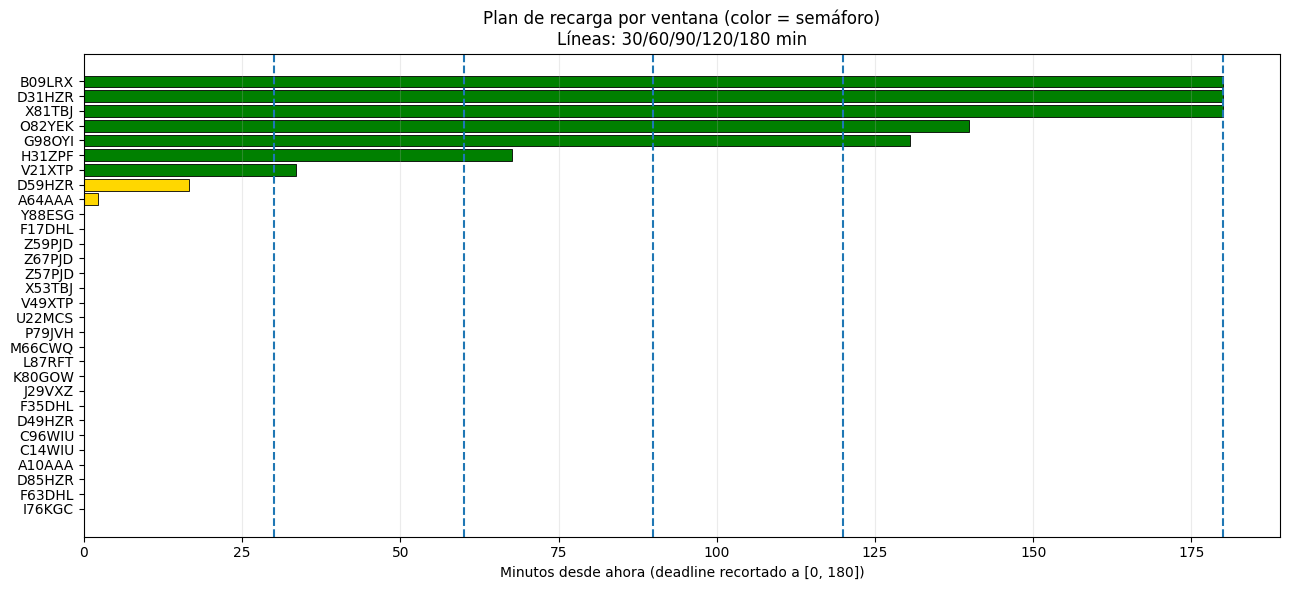


=== Instrucción operacional (según tu regla) ===

[ROJO] (21 equipos) -> MANDAR AHORA (0–30)
equipo_id  deadline_min        plan_ventana
   I76KGC   -368.688809 MANDAR AHORA (0–30)
   F63DHL   -257.841097 MANDAR AHORA (0–30)
   D85HZR   -248.170336 MANDAR AHORA (0–30)
   A10AAA   -238.644903 MANDAR AHORA (0–30)
   C14WIU   -238.644903 MANDAR AHORA (0–30)
   C96WIU   -238.644903 MANDAR AHORA (0–30)
   D49HZR   -238.644903 MANDAR AHORA (0–30)
   F35DHL   -238.644903 MANDAR AHORA (0–30)
   J29VXZ   -238.644903 MANDAR AHORA (0–30)
   K80GOW   -238.644903 MANDAR AHORA (0–30)

[AMARILLO] (2 equipos) -> MANDAR EN 60
equipo_id  deadline_min plan_ventana
   A64AAA      2.208203 MANDAR EN 60
   D59HZR     16.593280 MANDAR EN 60

[VERDE] (106 equipos) -> MANDAR EN 90+
equipo_id  deadline_min  plan_ventana
   V21XTP     33.565141 MANDAR EN 90+
   H31ZPF     67.636859 MANDAR EN 90+
   G98OYI    130.606608 MANDAR EN 90+
   O82YEK    139.786071 MANDAR EN 90+
   X81TBJ    210.681197 MANDAR EN 90+
   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

TOP_N = 30  # para ver más equipos

dfp = df_now_ok.copy()

# Asegurar prio
order_map = {"ROJO": 0, "AMARILLO": 1, "VERDE": 2}
dfp["prio"] = dfp["semaforo"].map(order_map).fillna(9).astype(int)
dfp = dfp.sort_values(["prio", "deadline_min"], ascending=[True, True]).reset_index(drop=True)

# La regla de planificación por ventana 
dfp["plan_ventana"] = np.select(
    [dfp["semaforo"] == "ROJO", dfp["semaforo"] == "AMARILLO", dfp["semaforo"] == "VERDE"],
    ["MANDAR AHORA (0–30)", "MANDAR EN 60", "MANDAR EN 90+"],
    default="REVISAR"
)

# Para que el gráfico NO muestre -300 min:
# - si está atrasado (deadline<0), lo mostramos como 0 y lo marcamos como "ATRASADO X min"
dfp["deadline_clip"] = dfp["deadline_min"].clip(lower=0, upper=180)
dfp["nota_deadline"] = np.where(
    dfp["deadline_min"] < 0,
    "ATRASADO",
    "OK"
)

# Mostrar resumen de conteo (5 rojos, 23 amarillos, etc.)
print("\n=== Conteo por semáforo ===")
print(dfp["semaforo"].value_counts())

print("\n=== Conteo por plan_ventana ===")
print(dfp["plan_ventana"].value_counts())

# Tabla para explicar (top urgentes)
cols = ["equipo_id","fuel_now_pct","fuel_pred_30","fuel_pred_60","fuel_pred_90",
        "deadline_min","semaforo","plan_ventana"]
print("\n=== Top equipos (priorizados) ===")
print(dfp[cols].head(40).to_string(index=False))

# -----------------------------
# Gráfico “Plan por ventana” (barras + color)
# -----------------------------
color_map = {"ROJO":"red", "AMARILLO":"gold", "VERDE":"green"}

dshow = dfp.head(TOP_N).copy()
y = np.arange(len(dshow))

plt.figure(figsize=(13, 6))
plt.barh(
    y,
    dshow["deadline_clip"].values,
    color=dshow["semaforo"].map(color_map).fillna("gray").values,
    edgecolor="black",
    linewidth=0.6
)

plt.axvline(30, linestyle="--")
plt.axvline(60, linestyle="--")
plt.axvline(90, linestyle="--")
plt.axvline(120, linestyle="--")
plt.axvline(180, linestyle="--")

plt.yticks(y, dshow["equipo_id"])
plt.xlabel("Minutos desde ahora (deadline recortado a [0, 180])")
plt.title("Plan de recarga por ventana (color = semáforo)\n"
          "Líneas: 30/60/90/120/180 min")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------------
# Texto tipo “instrucciones”
# -----------------------------
print("\n=== Instrucción operacional (según tu regla) ===")
for s in ["ROJO", "AMARILLO", "VERDE"]:
    sub = dfp[dfp["semaforo"] == s].copy()
    print(f"\n[{s}] ({len(sub)} equipos) -> {sub['plan_ventana'].iloc[0] if len(sub)>0 else ''}")
    # Mostrar los primeros 10 de cada categoría
    print(sub[["equipo_id","deadline_min","plan_ventana"]].head(10).to_string(index=False))


=== Selección para gráfico ===
ROJO: 5 AMARILLO: 2 VERDE: 3


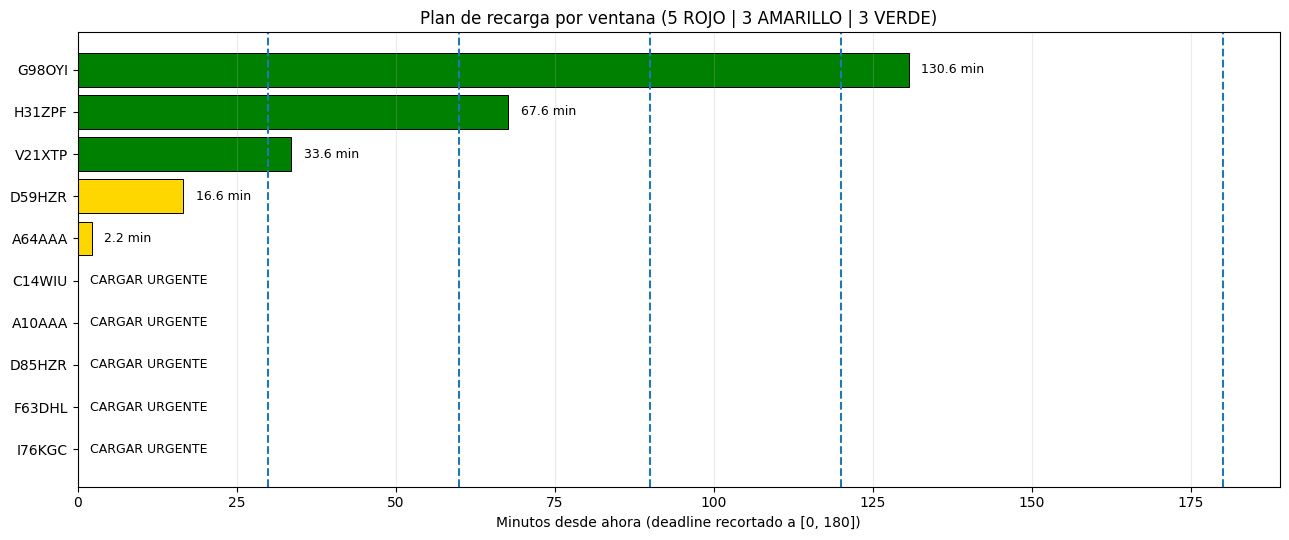

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# REQUIERE: df_now_ok con columnas
#   equipo_id, deadline_min, semaforo
# (y opcional: fuel_now_pct, fuel_pred_30/60/90 si quieres imprimir)
# =========================

WINDOW_MIN = 180
CUTS = [30, 60, 90, 120, 180]

# quieres mostrar:
SHOW_COUNTS = {"ROJO": 5, "AMARILLO": 3, "VERDE": 3}

# colores reales
color_map = {"ROJO": "red", "AMARILLO": "gold", "VERDE": "green"}

# ordenar por urgencia
order_map = {"ROJO": 0, "AMARILLO": 1, "VERDE": 2}
dfp = df_now_ok.copy()
dfp["prio"] = dfp["semaforo"].map(order_map).fillna(9).astype(int)
dfp = dfp.sort_values(["prio", "deadline_min"], ascending=[True, True]).reset_index(drop=True)

# seleccionar 5/3/3 por semáforo
rojos = dfp[dfp["semaforo"] == "ROJO"].sort_values("deadline_min").head(SHOW_COUNTS["ROJO"])
amas  = dfp[dfp["semaforo"] == "AMARILLO"].sort_values("deadline_min").head(SHOW_COUNTS["AMARILLO"])
verds = dfp[dfp["semaforo"] == "VERDE"].sort_values("deadline_min").head(SHOW_COUNTS["VERDE"])

dshow = pd.concat([rojos, amas, verds], ignore_index=True)

# si alguna categoría viene vacía, lo avisamos (sin romper)
print("\n=== Selección para gráfico ===")
print("ROJO:", len(rojos), "AMARILLO:", len(amas), "VERDE:", len(verds))

# deadline recortado para ventana 0..180 (si es negativo, se dibuja 0)
dshow["deadline_clip"] = dshow["deadline_min"].clip(lower=0, upper=WINDOW_MIN)

# etiqueta más clara: si estaba atrasado, lo marcamos
dshow["label_deadline"] = np.where(
    dshow["deadline_min"] < 0,
    "CARGAR URGENTE",
    dshow["deadline_min"].round(1).astype(str) + " min"
)

# =========================
# GRAFICO
# =========================
y = np.arange(len(dshow))

plt.figure(figsize=(13, 5.5))
plt.barh(
    y,
    dshow["deadline_clip"].values,
    color=dshow["semaforo"].map(color_map).fillna("gray").values,
    edgecolor="black",
    linewidth=0.7
)

# líneas guía
for c in CUTS:
    plt.axvline(c, linestyle="--")

# eje y con IDs
plt.yticks(y, dshow["equipo_id"])
plt.xlabel("Minutos desde ahora (deadline recortado a [0, 180])")
plt.title("Plan de recarga por ventana (5 ROJO | 3 AMARILLO | 3 VERDE)")

# anotar texto al final de cada barra (deadline real o 'ATRASADO')
for i, (x_end, txt) in enumerate(zip(dshow["deadline_clip"].values, dshow["label_deadline"].values)):
    plt.text(x_end + 2, i, txt, va="center", fontsize=9)

plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()